In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("dataset/olist_customers_dataset.csv")
geolocation = pd.read_csv("dataset/olist_geolocation_dataset.csv")
order_items = pd.read_csv("dataset/olist_order_items_dataset.csv")
payments = pd.read_csv("dataset/olist_order_payments_dataset.csv")
reviews = pd.read_csv("dataset/olist_order_reviews_dataset.csv")
orders = pd.read_csv("dataset/olist_orders_dataset.csv")
products = pd.read_csv("dataset/olist_products_dataset.csv")
sellers = pd.read_csv("dataset/olist_sellers_dataset.csv")
category_translation = pd.read_csv("dataset/product_category_name_translation.csv")

In [3]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
geolocation (1000163, 5)
order_items (112650, 7)
payments (103886, 5)
reviews (99224, 7)
orders (99441, 8)
products (32951, 9)
sellers (3095, 4)
category_translation (71, 2)


## Orders table

In [4]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [7]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [10]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

What is the status distribution of Olist orders?

In [11]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [12]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

In [13]:
delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [14]:
delivered_orders["late_delivery"] = (
    delivered_orders["delivery_delay_days"] > 0
).astype(int)

In [15]:
delivered_orders["late_delivery"].value_counts()

late_delivery
0    88652
1     7826
Name: count, dtype: int64

In [16]:
delivered_orders["late_delivery"].value_counts(normalize=True) * 100

late_delivery
0    91.888306
1     8.111694
Name: proportion, dtype: float64

In [17]:
delivered_orders["delivery_delay_days"].describe()

count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_delay_days, dtype: float64

Duplicate rows

In [18]:
orders.duplicated().sum()

np.int64(0)

In [19]:
orders["order_id"].duplicated().sum()

np.int64(0)

Missing values

In [20]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [21]:
orders.isnull().mean().mul(100).round(2)

order_id                         0.00
customer_id                      0.00
order_status                     0.00
order_purchase_timestamp         0.00
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
order_estimated_delivery_date    0.00
dtype: float64

In [22]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [23]:
orders["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [24]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

ID uniqueness

In [25]:
print("Rows:", len(orders))
print("Unique order_id:", orders["order_id"].nunique())
print("Unique customer_id:", orders["customer_id"].nunique())

Rows: 99441
Unique order_id: 99441
Unique customer_id: 99441


In [26]:
print("Total rows:", len(orders))
print("Unique order_id:", orders["order_id"].nunique())
print("Duplicate full rows:", orders.duplicated().sum())
print("Duplicate order_id:", orders["order_id"].duplicated().sum())

Total rows: 99441
Unique order_id: 99441
Duplicate full rows: 0
Duplicate order_id: 0


In [27]:
print(
    "Purchase after estimated delivery:",
    (orders["order_purchase_timestamp"] > orders["order_estimated_delivery_date"]).sum()
)

print(
    "Delivered before purchase:",
    (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]).sum()
)

print(
    "Carrier delivery before purchase:",
    (orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"]).sum()
)

Purchase after estimated delivery: 0
Delivered before purchase: 0
Carrier delivery before purchase: 166


In [28]:
orders.groupby("order_status")[
    [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].apply(lambda x: x.isna().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [29]:
carrier_before_purchase = orders[
    orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"]
].copy()

carrier_before_purchase[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].head(20)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
615,b9afddbdcfadc9a87b41a83271c3e888,delivered,2018-08-16 13:50:48,2018-08-16 14:05:13,2018-08-16 13:27:00,2018-08-24 14:58:37,2018-09-04
1111,ad133696906f6a78826daa0911b7daec,delivered,2018-06-15 15:41:22,2018-06-15 16:19:23,2018-06-15 14:52:00,2018-06-22 18:09:37,2018-07-18
1329,74e033208dc13a7b8127eb8e73d09b76,delivered,2018-05-02 10:48:44,2018-05-02 11:13:45,2018-05-02 09:49:00,2018-05-07 23:06:36,2018-05-29
1372,a6b58794fd2ba533359a76c08df576e3,delivered,2018-05-14 15:18:23,2018-05-14 15:33:35,2018-05-14 13:46:00,2018-05-19 19:33:32,2018-06-08
1864,5792e0b1c8c8a2bf53af468c9a422c88,delivered,2018-07-26 13:25:14,2018-07-26 13:35:14,2018-07-26 12:42:00,2018-07-30 14:45:02,2018-08-09
2760,c3eb293fd154223498b6551a728203e8,delivered,2018-07-19 14:06:04,2018-07-19 14:22:51,2018-07-19 13:49:00,2018-07-24 19:35:36,2018-08-06
3473,b0c2a7d04b165525254254a728c50a4e,delivered,2018-06-07 13:28:30,2018-06-07 13:57:22,2018-06-07 13:22:00,2018-06-21 17:36:43,2018-07-04
3661,2033a4586b5bec3229ebc1675a8ae092,delivered,2018-06-12 10:10:25,2018-06-12 10:39:59,2018-06-12 10:09:00,2018-06-19 14:08:27,2018-07-19
4114,08adcddad19d3acf37d1fa01cb9ded1e,delivered,2018-06-27 11:16:44,2018-06-27 11:30:56,2018-06-27 10:57:00,2018-06-29 17:39:53,2018-07-18
4159,dee6298ce7d1fb2645141ef9972157aa,shipped,2018-04-30 14:06:12,2018-04-30 14:15:24,2018-04-30 12:59:00,NaT,2018-05-28


In [30]:
carrier_before_purchase["order_status"].value_counts()

order_status
delivered    165
shipped        1
Name: count, dtype: int64

In [31]:
print(
    "Approval before purchase:",
    (orders["order_approved_at"] < orders["order_purchase_timestamp"]).sum()
)

print(
    "Carrier before approval:",
    (
        orders["order_delivered_carrier_date"]
        < orders["order_approved_at"]
    ).sum()
)

print(
    "Customer delivery before carrier:",
    (
        orders["order_delivered_customer_date"]
        < orders["order_delivered_carrier_date"]
    ).sum()
)

Approval before purchase: 0
Carrier before approval: 1359
Customer delivery before carrier: 23


In [32]:
customer_before_carrier = orders[
    orders["order_delivered_customer_date"]
    < orders["order_delivered_carrier_date"]
].copy()

customer_before_carrier[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14
9553,383aa8b2724fe452d9ccd9934a8c628b,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21
13487,cb1134f9010d242e9515ad1c78ec0c39,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08
14474,dceb62e8fa94b46006c9554fed743df0,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11
19268,5f9d46795c3126674e52becb3a1a517f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31
21338,8c78d01de3a9009e23d6877a7cc9be20,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30
22520,b27af682321527a6349f1761eb3f360c,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14
25393,1cc3ae63caffff2d6c3ee3e78e074acf,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25
25646,e37f11cae9985ca58f0b56f268720537,delivered,2017-07-26 11:46:34,2017-07-27 10:10:16,2017-08-01 18:17:47,2017-07-31 17:49:56,2017-08-24
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,2017-08-18


In [33]:
customer_before_carrier.shape

(23, 8)

In [34]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

## conclusion of order table:
Data quality findings: The orders table contains no duplicate order IDs or duplicate rows. Datetime columns were converted to datetime format. Missing delivery timestamps are associated with different order statuses and were retained rather than imputed because they can reflect incomplete order lifecycles. A small number of records contain inconsistent event timestamps, such as carrier/customer delivery events occurring out of chronological order. These records will be retained in the raw dataset and handled appropriately in downstream analyses.

## Customers table

In [35]:
customers.shape

(99441, 5)

In [36]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [37]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [38]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [39]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [40]:
customers.duplicated().sum()

np.int64(0)

In [41]:
customers["customer_id"].nunique()

99441

In [42]:
customers["customer_unique_id"].duplicated().sum()

np.int64(3345)

In [43]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [44]:
customers["customer_city"].nunique()

4119

In [45]:
customer_repeat = (
    customers.groupby("customer_unique_id")
    .size()
    .sort_values(ascending=False)
)

customer_repeat.head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
63cfc61cee11cbe306bff5857d00bfe4     6
dc813062e0fc23409cd255f7f53c7074     6
de34b16117594161a6a89c50b289d35a     6
dtype: int64

In [46]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

customer_orders.shape

(99441, 12)

In [47]:
customer_orders["customer_unique_id"].isna().sum()

np.int64(0)

In [48]:
customer_orders = (
    customers.groupby("customer_unique_id")
    .agg(
        customer_ids=("customer_id", "nunique"),
        orders=("customer_id", "count")
    )
    .sort_values("orders", ascending=False)
)

customer_orders.head(10)

,customer_ids,orders
customer_unique_id,,
8d50f5eadf50201ccdcedfb9e2ac8455,17,17
3e43e6105506432c953e165fb2acf44c,9,9
1b6c7548a2a1f9037c1fd3ddfed95f33,7,7
6469f99c1f9dfae7733b25662e7f1782,7,7
ca77025e7201e3b30c44b472ff346268,7,7
47c1a3033b8b77b3ab6e109eb4d5fdf3,6,6
12f5d6e1cbf93dafd9dcc19095df0b3d,6,6
63cfc61cee11cbe306bff5857d00bfe4,6,6
dc813062e0fc23409cd255f7f53c7074,6,6


In [49]:
customer_orders["orders"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: orders, dtype: float64

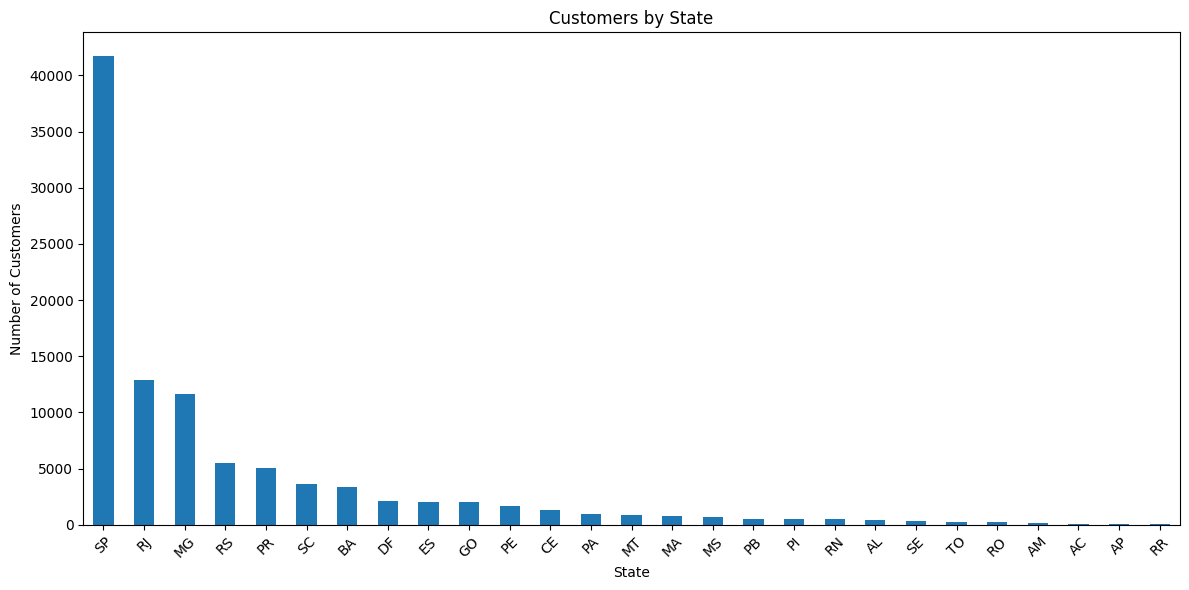

In [50]:
import matplotlib.pyplot as plt

state_counts = customers["customer_state"].value_counts()

plt.figure(figsize=(12, 6))
state_counts.plot(kind="bar")

plt.title("Customers by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
state_percentage = (
    customers["customer_state"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

state_percentage.head(10)

customer_state
SP    41.98
RJ    12.92
MG    11.70
RS     5.50
PR     5.07
SC     3.66
BA     3.40
DF     2.15
ES     2.04
GO     2.03
Name: proportion, dtype: float64

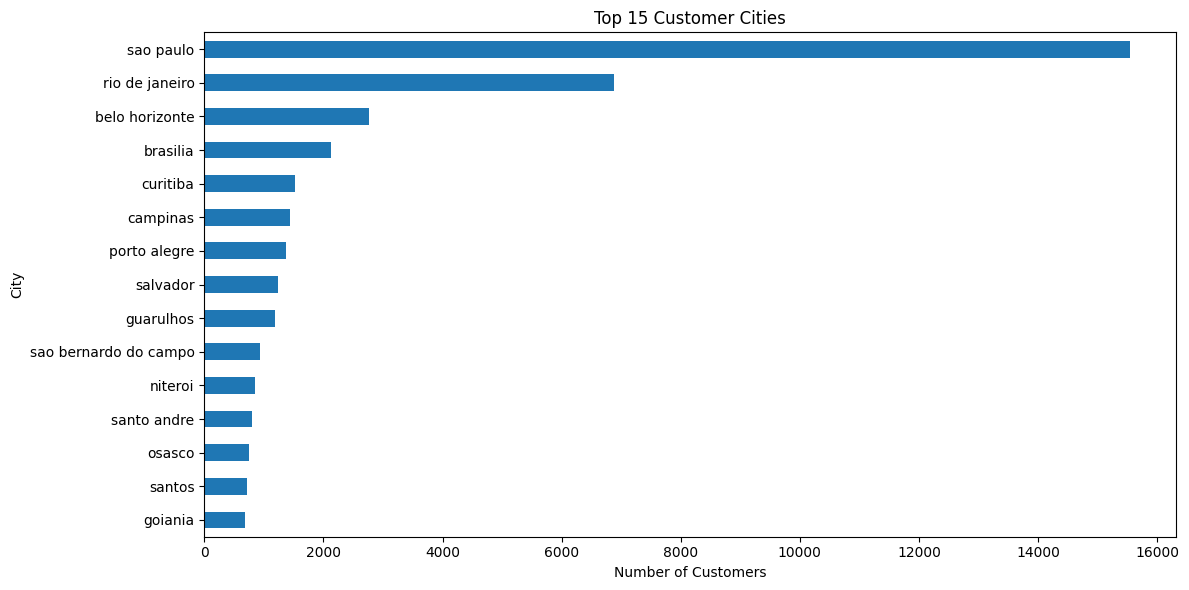

In [52]:
top_cities = customers["customer_city"].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_cities.sort_values().plot(kind="barh")

plt.title("Top 15 Customer Cities")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [53]:
customer_orders_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

customer_orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [54]:
customer_orders_df["customer_state"].isna().sum()

np.int64(0)

In [55]:
customer_orders_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

customer_orders_df["late_delivery"] = (
    customer_orders_df["order_delivered_customer_date"]
    > customer_orders_df["order_estimated_delivery_date"]
).astype("Int64")

In [56]:
customer_orders_df["late_delivery"].value_counts(dropna=False)

late_delivery
0    91614
1     7827
Name: count, dtype: Int64

In [57]:
orders_by_state = (
    customer_orders_df[
        customer_orders_df["order_delivered_customer_date"].notna()
    ]
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("late_delivery", "sum")
    )
)

orders_by_state["late_rate"] = (
    orders_by_state["late_orders"]
    / orders_by_state["total_orders"]
    * 100
)

orders_by_state.sort_values(
    "late_rate",
    ascending=False
).head(10)

,total_orders,late_orders,late_rate
customer_state,,,
AL,397,95,23.929471
MA,717,141,19.665272
PI,476,76,15.966387
CE,1279,196,15.324472
SE,335,51,15.223881
BA,3256,457,14.035627
RJ,12353,1664,13.470412
TO,274,35,12.773723
PA,946,117,12.367865


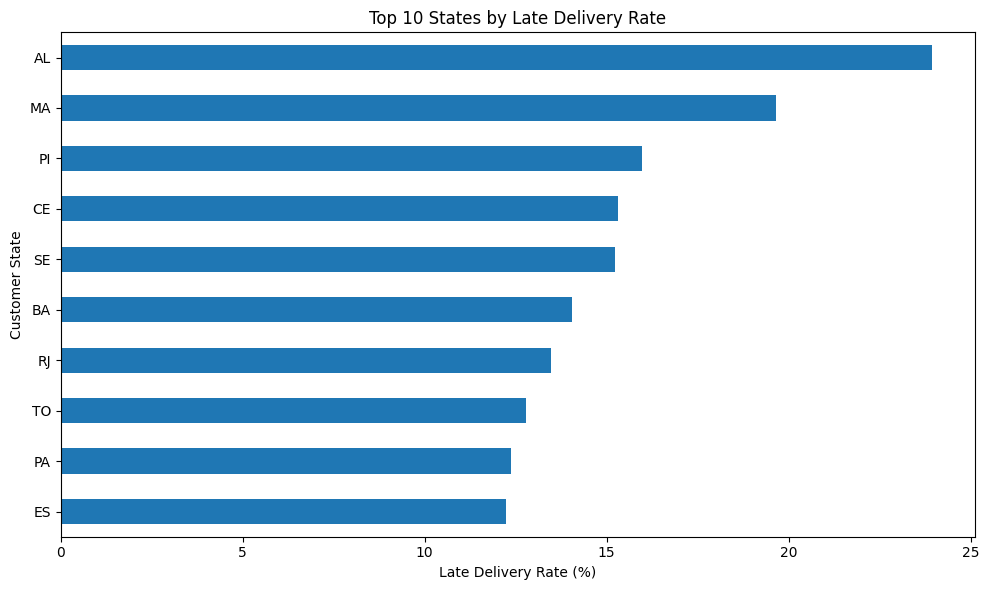

In [58]:
top_states = (
    orders_by_state
    .sort_values("late_rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_states["late_rate"].sort_values().plot(kind="barh")

plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

## order_items table

In [63]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [64]:
order_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [65]:
order_items.duplicated().sum()

np.int64(0)

In [66]:
order_items.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

In [67]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [68]:
order_items.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


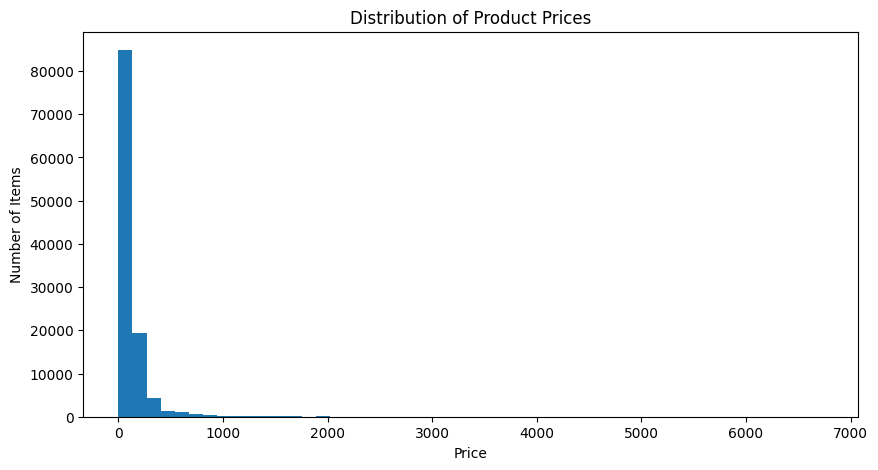

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(order_items["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of Items")
plt.title("Distribution of Product Prices")
plt.show()

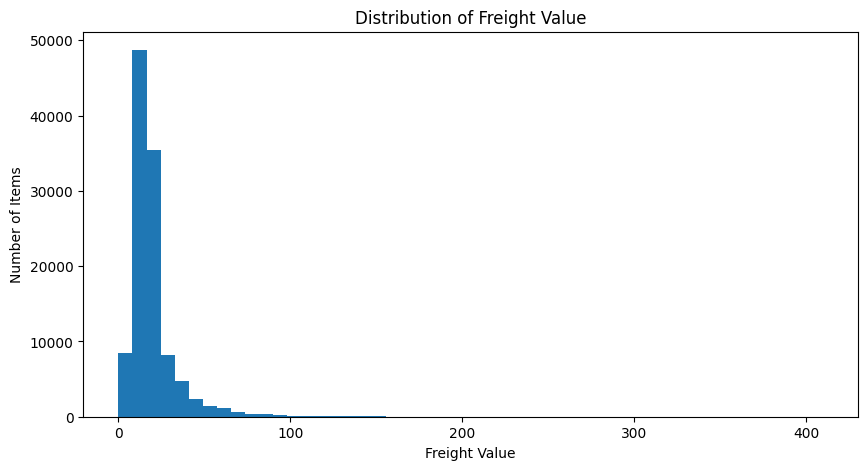

In [70]:
plt.figure(figsize=(10,5))
plt.hist(order_items["freight_value"], bins=50)
plt.xlabel("Freight Value")
plt.ylabel("Number of Items")
plt.title("Distribution of Freight Value")
plt.show()

In [71]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

In [72]:
order_items.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

 ### Distribution of price

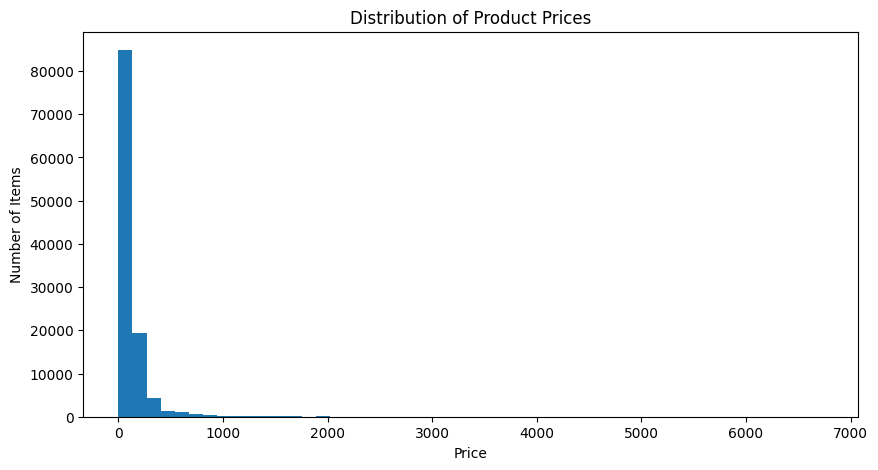

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(order_items["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of Items")
plt.title("Distribution of Product Prices")
plt.show()

In [74]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [75]:
order_items["price"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     229.80000
0.950     349.90000
0.990     890.00000
0.995    1218.08265
0.999    2110.00000
Name: price, dtype: float64

### Freight value

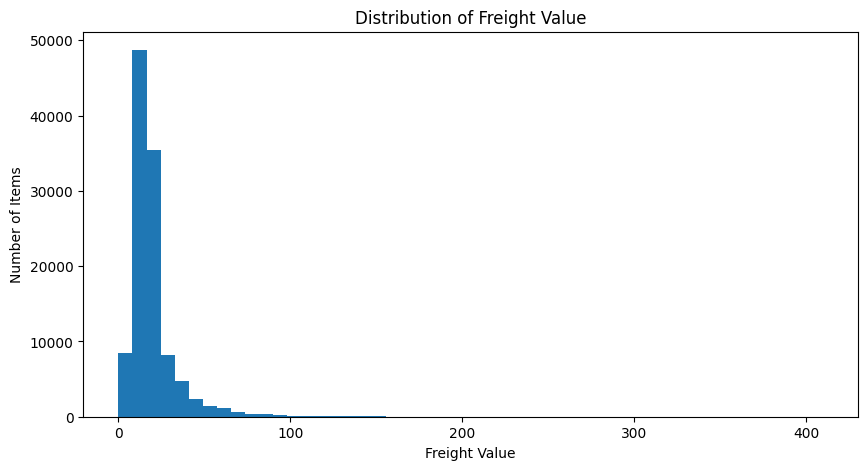

In [76]:
plt.figure(figsize=(10,5))
plt.hist(order_items["freight_value"], bins=50)
plt.xlabel("Freight Value")
plt.ylabel("Number of Items")
plt.title("Distribution of Freight Value")
plt.show()

In [77]:
order_items["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [78]:
order_items["freight_value"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     34.04100
0.950     45.12000
0.990     84.52000
0.995    106.22510
0.999    175.59212
Name: freight_value, dtype: float64

### Price vs Freight

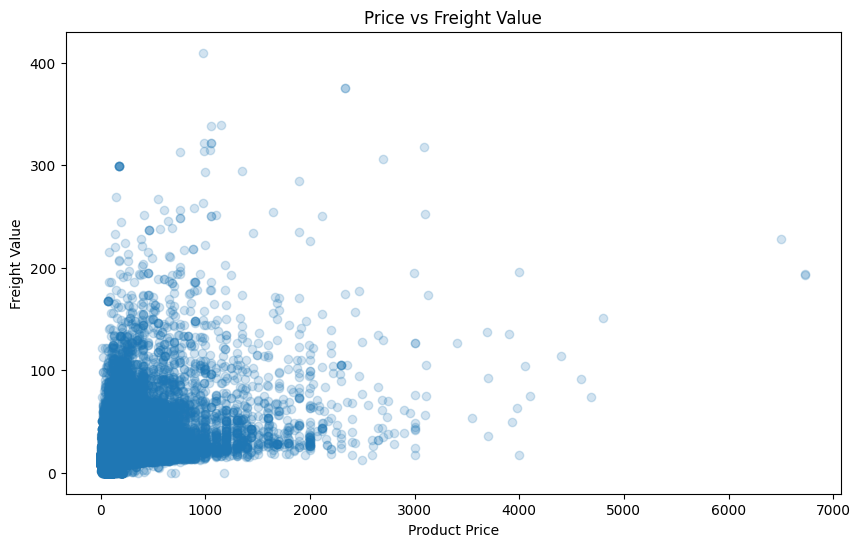

In [79]:
plt.figure(figsize=(10,6))
plt.scatter(
    order_items["price"],
    order_items["freight_value"],
    alpha=0.2
)

plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.title("Price vs Freight Value")
plt.show()

In [80]:
order_items[["price", "freight_value"]].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


In [81]:
items_per_order = (
    order_items
    .groupby("order_id")["order_item_id"]
    .count()
)

In [82]:
items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: order_item_id, dtype: float64

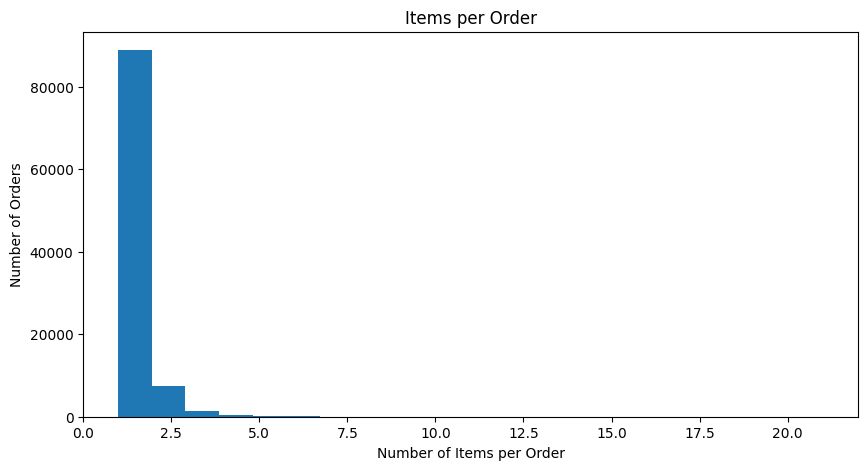

In [83]:
plt.figure(figsize=(10,5))
plt.hist(items_per_order, bins=21)
plt.xlabel("Number of Items per Order")
plt.ylabel("Number of Orders")
plt.title("Items per Order")
plt.show()

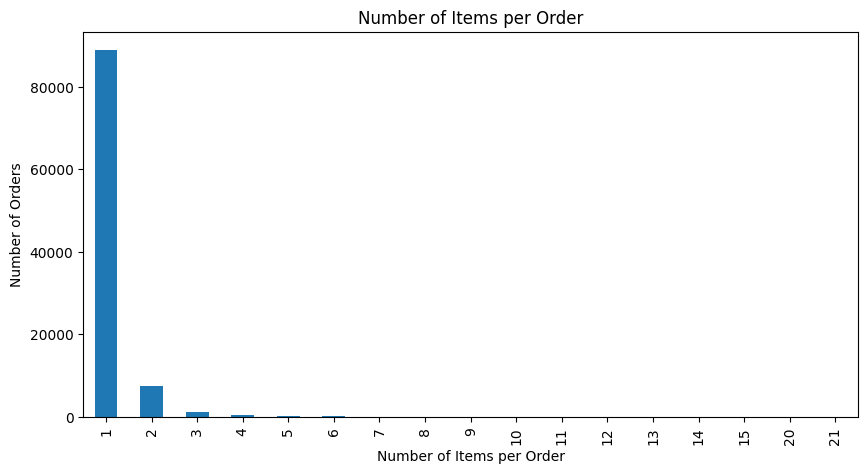

In [84]:
plt.figure(figsize=(10, 5))

items_per_order.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of Items per Order")
plt.ylabel("Number of Orders")
plt.title("Number of Items per Order")

plt.show()

In [85]:
items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: order_item_id, dtype: float64

In [86]:
items_per_order.value_counts().sort_index()

order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

In [87]:
order_features = (
    order_items
    .groupby("order_id")
    .agg(
        items_count=("order_item_id", "count"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        avg_price=("price", "mean"),
        seller_count=("seller_id", "nunique")
    )
    .reset_index()
)

In [88]:
order_features.describe()

,items_count,total_price,total_freight,avg_price,seller_count
count,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000
mean,1.141731,137.754076,22.823562,125.919255,1.013622
std,0.538452,210.645145,21.650909,190.985636,0.122297
min,1.000000,0.850000,0.000000,0.850000,1.000000
25%,1.000000,45.900000,13.850000,41.990000,1.000000
50%,1.000000,86.900000,17.170000,79.000000,1.000000
75%,1.000000,149.900000,24.040000,139.900000,1.000000
max,21.000000,13440.000000,1794.960000,6735.000000,5.000000


In [89]:
order_features.head()

,order_id,items_count,total_price,total_freight,avg_price,seller_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,58.90,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,239.90,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,199.00,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,12.99,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,199.90,1


## Paymment table

In [90]:
payments.shape

(103886, 5)

In [91]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [92]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [93]:
payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [94]:
payments.duplicated().sum()

np.int64(0)

In [95]:
payments.nunique()

order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

In [96]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [97]:
payments["payment_type"].value_counts(normalize=True) * 100

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64

In [98]:
payments[["payment_sequential", "payment_installments", "payment_value"]].describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [99]:
payments["payment_installments"].value_counts().sort_index().head(20)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
Name: count, dtype: int64

In [100]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [101]:
payments["payment_value"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     297.27000
0.950     437.63500
0.990    1039.91650
0.995    1410.27575
0.999    2339.23325
Name: payment_value, dtype: float64

In [102]:
payments["payment_installments"].quantile([0.90, 0.95, 0.99, 0.999])

0.900     8.0
0.950    10.0
0.990    10.0
0.999    15.0
Name: payment_installments, dtype: float64

In [103]:
payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [104]:
payments["payment_sequential"].min(), payments["payment_sequential"].max()

(np.int64(1), np.int64(29))

In [105]:
payments["payment_installments"].min(), payments["payment_installments"].max()

(np.int64(0), np.int64(24))

In [106]:
payments["payment_value"].min(), payments["payment_value"].max()

(np.float64(0.0), np.float64(13664.08))

In [107]:
payments["order_id"].isin(orders["order_id"]).mean() * 100

np.float64(100.0)

In [108]:
payments[
    (payments["payment_installments"] == 0) |
    (payments["payment_type"] == "not_defined")
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.00
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.00
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.00


In [109]:
payments["payment_installments_clean"] = payments["payment_installments"]

payments.loc[
    payments["payment_installments_clean"] == 0,
    "payment_installments_clean"
] = np.nan

In [110]:
payments.loc[
    payments["payment_type"] == "credit_card",
    "payment_installments_clean"
].median()

np.float64(3.0)

In [111]:
payments.loc[
    (payments["payment_type"] == "credit_card") &
    (payments["payment_installments_clean"].isna()),
    "payment_installments_clean"
] = 1

In [112]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [113]:
payments[payments["payment_value"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_installments_clean
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0,1.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0,1.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0,1.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0,1.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0,1.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0,1.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0,1.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0,1.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0,1.0


In [114]:
# Create cleaned installments column
payments["payment_installments_clean"] = payments["payment_installments"].copy()

# Replace invalid 0 installments for credit card with the median
credit_card_median = payments.loc[
    payments["payment_type"] == "credit_card",
    "payment_installments"
].median()

payments.loc[
    (payments["payment_type"] == "credit_card") &
    (payments["payment_installments"] == 0),
    "payment_installments_clean"
] = credit_card_median

print("Credit card median:", credit_card_median)
print(
    payments["payment_installments_clean"]
    .value_counts()
    .sort_index()
)

Credit card median: 3.0
payment_installments_clean
1     52546
2     12413
3     10463
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64


In [115]:
payments[
    (payments["payment_type"] == "credit_card") &
    (payments["payment_installments_clean"] == 0)
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_installments_clean


### 1. Payment Type Distribution

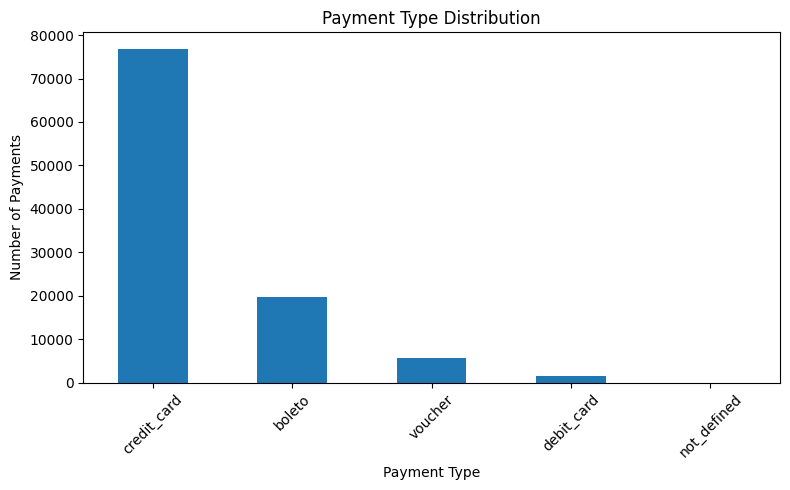

In [116]:
import matplotlib.pyplot as plt

payments["payment_type"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Payment Value Distribution

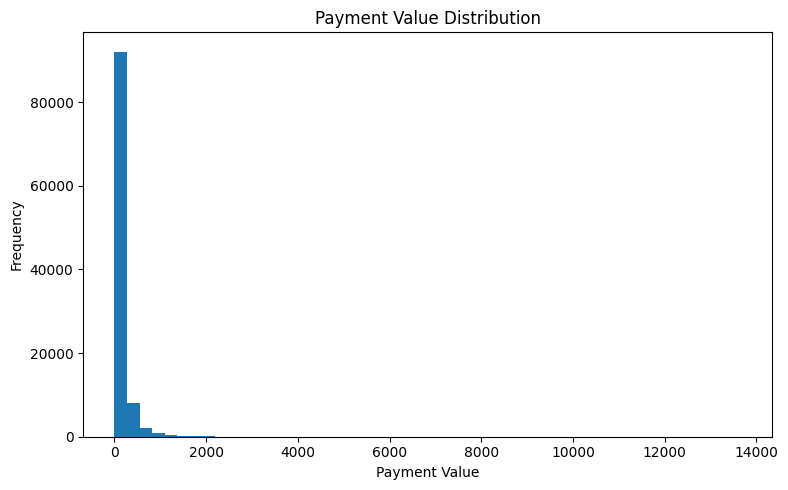

In [117]:
payments["payment_value"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 5)
)

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 3.Payment Value  without effect of extreme values

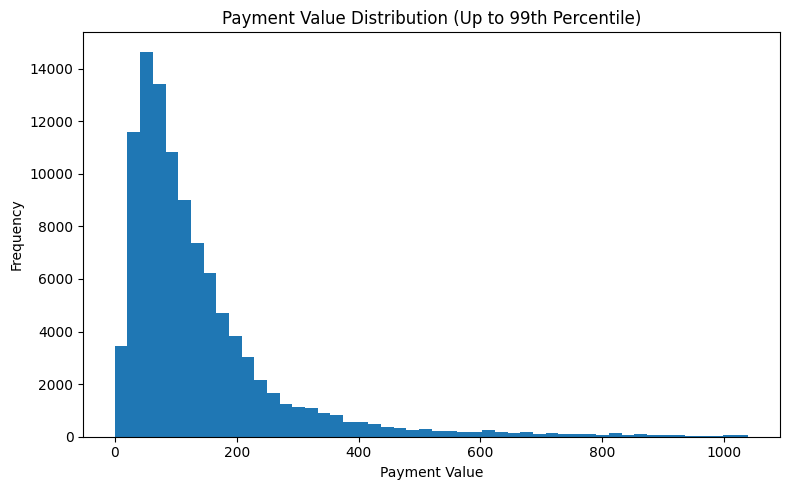

In [118]:
plt.figure(figsize=(8,5))

plt.hist(
    payments.loc[payments["payment_value"] <= payments["payment_value"].quantile(0.99),
                "payment_value"],
    bins=50
)

plt.title("Payment Value Distribution (Up to 99th Percentile)")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4. Installments Distribution

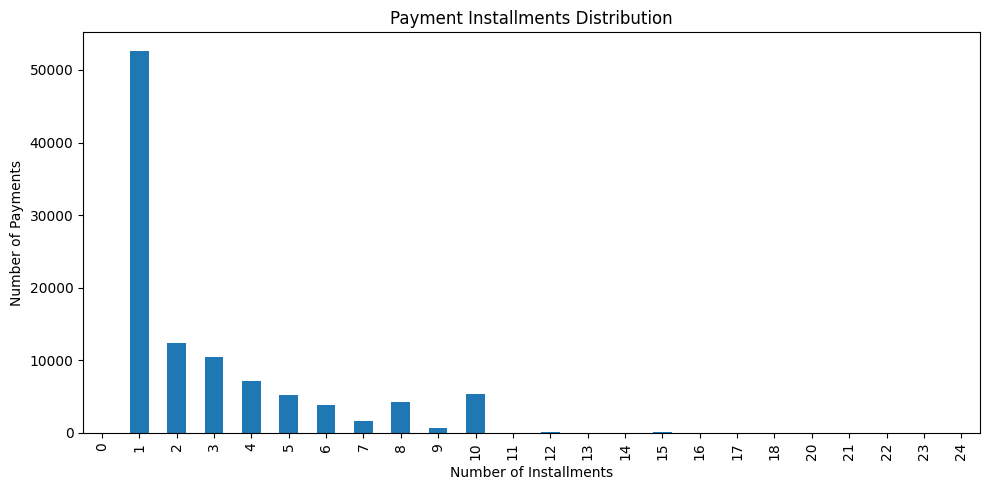

In [119]:
payments["payment_installments"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Payment Installments Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Payments")
plt.tight_layout()
plt.show()

### 5.Payment Type vs Payment Value

<Figure size 800x500 with 0 Axes>

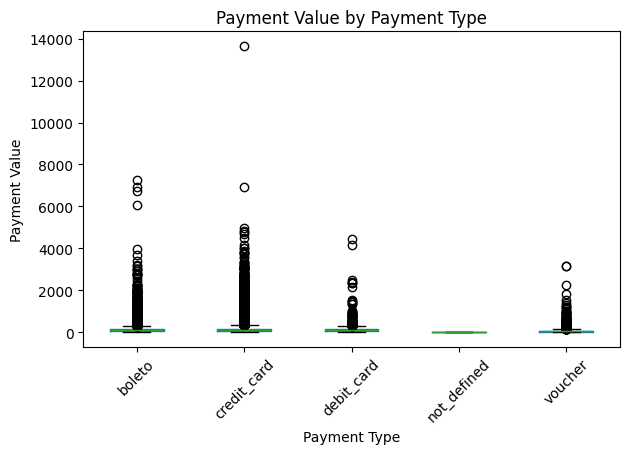

In [120]:
plt.figure(figsize=(8,5))

payments.boxplot(
    column="payment_value",
    by="payment_type",
    grid=False
)

plt.title("Payment Value by Payment Type")
plt.suptitle("")
plt.xlabel("Payment Type")
plt.ylabel("Payment Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [121]:
# =========================
# PAYMENT EDA SUMMARY
# =========================

print("=" * 60)
print("1. PAYMENT TYPE DISTRIBUTION")
print("=" * 60)

payment_type_summary = (
    payments["payment_type"]
    .value_counts()
    .to_frame("count")
)

payment_type_summary["percentage"] = (
    payment_type_summary["count"]
    / len(payments) * 100
)

print(payment_type_summary.round(2))


print("\n" + "=" * 60)
print("2. PAYMENT VALUE SUMMARY")
print("=" * 60)

print(payments["payment_value"].describe())


print("\nPayment Value Quantiles:")
print(
    payments["payment_value"]
    .quantile([0.90, 0.95, 0.99, 0.995, 0.999])
)


print("\n" + "=" * 60)
print("3. INSTALLMENTS DISTRIBUTION")
print("=" * 60)

print(
    payments["payment_installments_clean"]
    .value_counts()
    .sort_index()
)


print("\n" + "=" * 60)
print("4. PAYMENT VALUE BY PAYMENT TYPE")
print("=" * 60)

payment_by_type = (
    payments
    .groupby("payment_type")["payment_value"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_values("mean", ascending=False)
)

print(payment_by_type.round(2))


print("\n" + "=" * 60)
print("5. ZERO PAYMENT VALUES")
print("=" * 60)

zero_payment = payments[payments["payment_value"] == 0]

print("Number of zero-payment rows:", len(zero_payment))

print("\nZero payment by type:")
print(zero_payment["payment_type"].value_counts())


print("\n" + "=" * 60)
print("6. PAYMENT SEQUENTIAL")
print("=" * 60)

print(payments["payment_sequential"].describe())

print("\nTop payment sequential values:")
print(
    payments["payment_sequential"]
    .value_counts()
    .sort_index()
    .head(15)
)

1. PAYMENT TYPE DISTRIBUTION
              count  percentage
payment_type                   
credit_card   76795       73.92
boleto        19784       19.04
voucher        5775        5.56
debit_card     1529        1.47
not_defined       3        0.00

2. PAYMENT VALUE SUMMARY
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Payment Value Quantiles:
0.900     297.27000
0.950     437.63500
0.990    1039.91650
0.995    1410.27575
0.999    2339.23325
Name: payment_value, dtype: float64

3. INSTALLMENTS DISTRIBUTION
payment_installments_clean
1     52546
2     12413
3     10463
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: 

### products table

In [ ]:
print(products.shape)
print("=" * 60)

(32951, 9)
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            10

In [ ]:

print(products.head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [124]:
print(products.info())
print("=" * 60)

print(products.isna().sum())
print("=" * 60)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
prod

In [125]:
print("Duplicates:", products.duplicated().sum())
print("=" * 60)

print("Unique values:")
print(products.nunique())
print("=" * 60)


Duplicates: 0
Unique values:
product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64


In [126]:
print("Duplicates:", products.duplicated().sum())
print("=" * 60)

print("Unique values:")
print(products.nunique())
print("=" * 60)


Duplicates: 0
Unique values:
product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64


In [127]:
# Products with missing category
products[products["product_category_name"].isna()].head(20)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,2200.0,16.0,2.0,11.0
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.0,16.0,7.0,11.0
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.0,18.0,8.0,14.0
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.0,22.0,14.0,14.0
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,1400.0,25.0,25.0,25.0


In [128]:
# Check whether the 610 missing-category rows
# also have missing values in the other descriptive columns

missing_category = products["product_category_name"].isna()

products.loc[
    missing_category,
    [
        "product_id",
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty"
    ]
].isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
dtype: int64

In [129]:
products.loc[
    missing_category,
    [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty"
    ]
].notna().sum()

product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
dtype: int64

In [131]:
dimension_cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

products[products[dimension_cols].isna().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
int_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

In [134]:
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("unknown")
)

In [135]:
desc_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

products[desc_cols] = products[desc_cols].fillna(0)

In [137]:
dimension_cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in dimension_cols:
    products[col] = products[col].fillna(
        products[col].median()
    )

In [139]:
int_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

products[int_cols] = products[int_cols].astype("int64")

In [140]:
print(products.isna().sum())
print("=" * 60)

print(products.dtypes)
print("=" * 60)

print("Duplicates:", products.duplicated().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64
product_id                    object
product_category_name         object
product_name_lenght            int64
product_description_lenght     int64
product_photos_qty             int64
product_weight_g               int64
product_length_cm              int64
product_height_cm              int64
product_width_cm               int64
dtype: object
Duplicates: 0


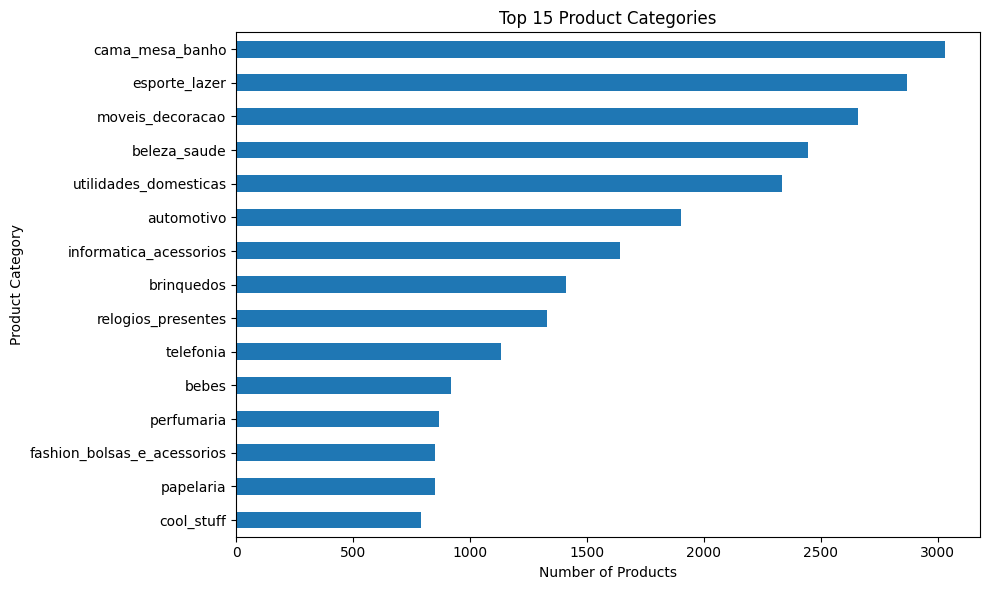

In [141]:
import matplotlib.pyplot as plt

top_categories = (
    products["product_category_name"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 15 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

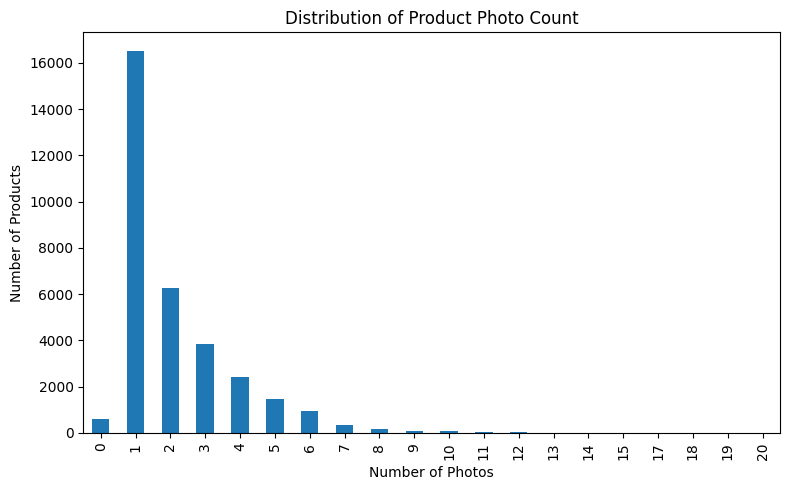

In [142]:
plt.figure(figsize=(8, 5))

products["product_photos_qty"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Product Photo Count")
plt.xlabel("Number of Photos")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

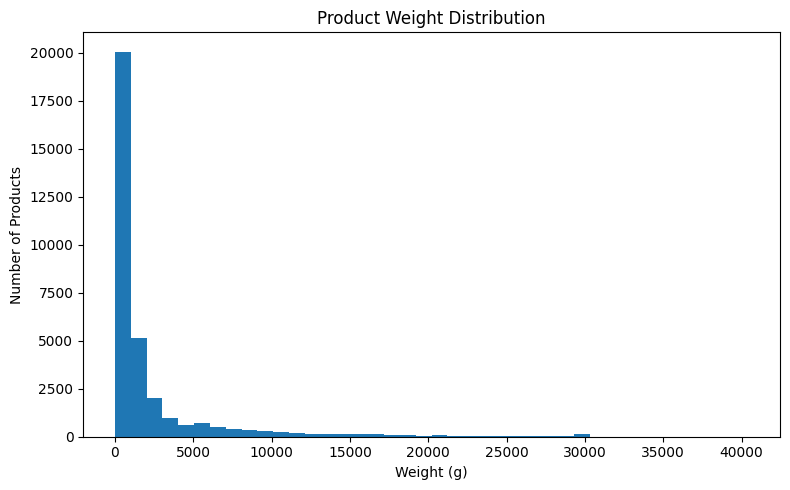

In [143]:
plt.figure(figsize=(8, 5))

products["product_weight_g"].plot(
    kind="hist",
    bins=40
)

plt.title("Product Weight Distribution")
plt.xlabel("Weight (g)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [144]:
print(products.isna().sum())
print(products.dtypes)
print("Duplicates:", products.duplicated().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64
product_id                    object
product_category_name         object
product_name_lenght            int64
product_description_lenght     int64
product_photos_qty             int64
product_weight_g               int64
product_length_cm              int64
product_height_cm              int64
product_width_cm               int64
dtype: object
Duplicates: 0


## Sellers table

In [149]:
print(sellers.shape)
print("=" * 60)

(3095, 4)


In [146]:
print(sellers.head())
print("=" * 60)


                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP  


In [147]:
print(sellers.info())
print("=" * 60)

print(sellers.isna().sum())
print("=" * 60)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
None
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [148]:

print("Duplicates:", sellers.duplicated().sum())
print("=" * 60)

print("Unique values:")
print(sellers.nunique())
print("=" * 60)

Duplicates: 0
Unique values:
seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64


In [150]:
print(sellers.describe(include="all").T)

                         count unique                               top  freq  \
seller_id                 3095   3095  9e25199f6ef7e7c347120ff175652c3b     1   
seller_zip_code_prefix  3095.0    NaN                               NaN   NaN   
seller_city               3095    611                         sao paulo   694   
seller_state              3095     23                                SP  1849   

                                mean          std     min     25%      50%  \
seller_id                        NaN          NaN     NaN     NaN      NaN   
seller_zip_code_prefix  32291.059451  32713.45383  1001.0  7093.5  14940.0   
seller_city                      NaN          NaN     NaN     NaN      NaN   
seller_state                     NaN          NaN     NaN     NaN      NaN   

                            75%      max  
seller_id                   NaN      NaN  
seller_zip_code_prefix  64552.5  99730.0  
seller_city                 NaN      NaN  
seller_state                NaN

In [158]:
print("Invalid ZIP codes:")
print(sellers[
    (sellers["seller_zip_code_prefix"] < 0) |
    (sellers["seller_zip_code_prefix"] > 99999)
])

Invalid ZIP codes:
Empty DataFrame
Columns: [seller_id, seller_zip_code_prefix, seller_city, seller_state]
Index: []


In [159]:
print(sellers["seller_state"].value_counts())

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64


In [160]:
print(
    sellers.groupby("seller_city")["seller_state"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

seller_city
marechal candido rondon    3
rio de janeiro             3
andradas                   2
ipira                      2
itajai                     2
blumenau                   2
caxias do sul              2
guaira                     2
jacutinga                  2
chapeco                    2
Name: seller_state, dtype: int64


### 1. Top 15 seller states

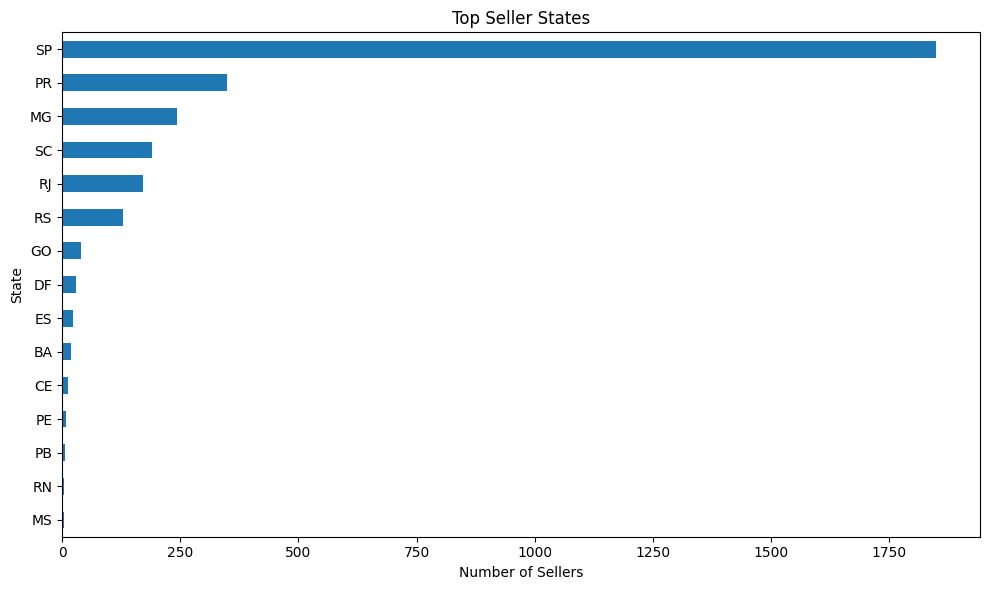

In [152]:
import matplotlib.pyplot as plt

top_seller_states = (
    sellers["seller_state"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

top_seller_states.sort_values().plot(kind="barh")

plt.title("Top Seller States")
plt.xlabel("Number of Sellers")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### 2. Top 15 seller cities

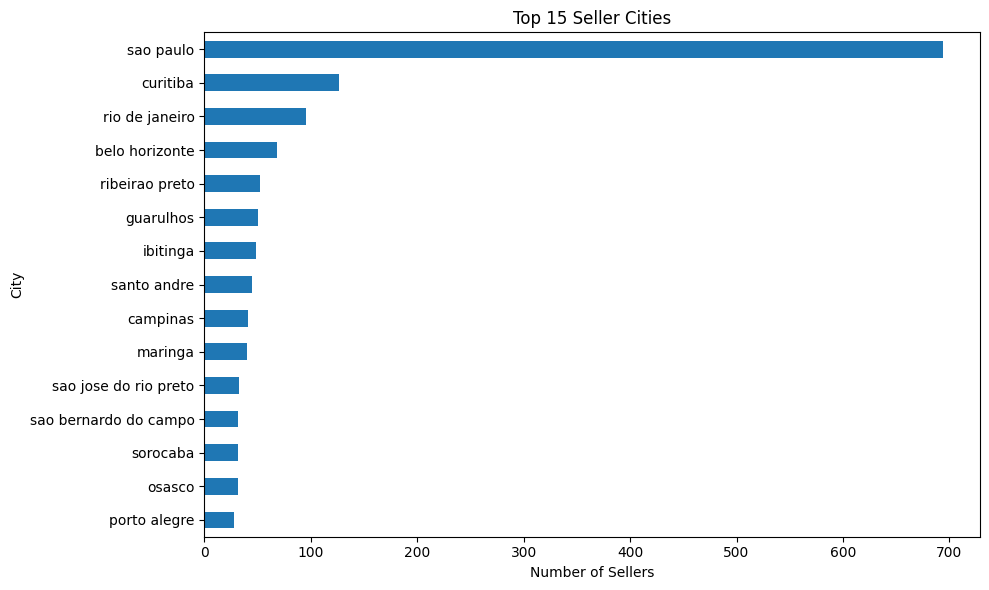

In [153]:
top_seller_cities = (
    sellers["seller_city"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

top_seller_cities.sort_values().plot(kind="barh")

plt.title("Top 15 Seller Cities")
plt.xlabel("Number of Sellers")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### 3. Seller distribution by state — percentage

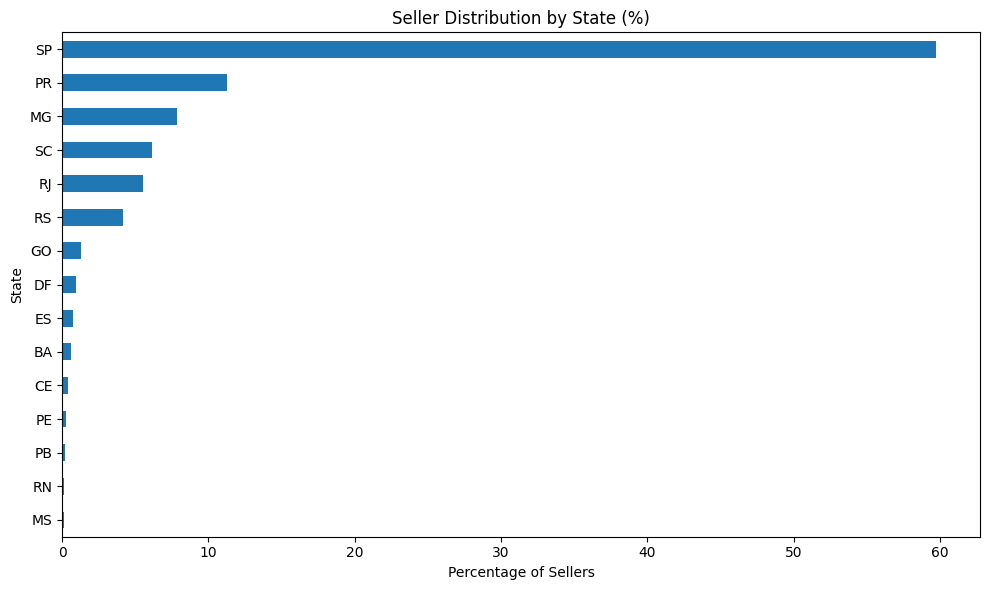

In [154]:
seller_state_pct = (
    sellers["seller_state"]
    .value_counts(normalize=True)
    .head(15)
    .mul(100)
)

plt.figure(figsize=(10, 6))

seller_state_pct.sort_values().plot(kind="barh")

plt.title("Seller Distribution by State (%)")
plt.xlabel("Percentage of Sellers")
plt.ylabel("State")

plt.tight_layout()
plt.show()

## Geolocation table

In [165]:
print(geolocation.shape)
print("=" * 60)

(1000163, 5)


In [161]:
print(geolocation.head())
print("=" * 60)

   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   
3                         1041       -23.544392       -46.639499   
4                         1035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


In [162]:
print(geolocation.info())
print("=" * 60)

print(geolocation.isna().sum())
print("=" * 60)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB
None
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [163]:
print("Duplicates:", geolocation.duplicated().sum())
print("=" * 60)

print(geolocation.nunique())
print("=" * 60)


Duplicates: 261831
geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64


In [164]:
print(geolocation.describe(include="all").T)

                                 count unique        top    freq  \
geolocation_zip_code_prefix  1000163.0    NaN        NaN     NaN   
geolocation_lat              1000163.0    NaN        NaN     NaN   
geolocation_lng              1000163.0    NaN        NaN     NaN   
geolocation_city               1000163   8011  sao paulo  135800   
geolocation_state              1000163     27         SP  404268   

                                     mean          std         min        25%  \
geolocation_zip_code_prefix  36574.166466  30549.33571      1001.0    11075.0   
geolocation_lat                -21.176153     5.715866  -36.605374 -23.603546   
geolocation_lng                -46.390541     4.269748 -101.466766 -48.573172   
geolocation_city                      NaN          NaN         NaN        NaN   
geolocation_state                     NaN          NaN         NaN        NaN   

                                   50%        75%         max  
geolocation_zip_code_prefix    26530.0  

In [166]:
# Exact duplicates
exact_duplicates = geolocation.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

# Duplicate ZIP codes
zip_duplicates = geolocation["geolocation_zip_code_prefix"].duplicated().sum()

print("Duplicate ZIP code rows:", zip_duplicates)

# Number of unique ZIP codes
print("Unique ZIP codes:", geolocation["geolocation_zip_code_prefix"].nunique())

Exact duplicate rows: 261831
Duplicate ZIP code rows: 981148
Unique ZIP codes: 19015


In [167]:
# How many different coordinates does each ZIP code have?
zip_coord_counts = (
    geolocation
    .groupby("geolocation_zip_code_prefix")
    .agg(
        coordinate_count=(
            "geolocation_lat",
            "nunique"
        )
    )
    .sort_values("coordinate_count", ascending=False)
)

print(zip_coord_counts.head(20))

                             coordinate_count
geolocation_zip_code_prefix                  
38400                                     746
11680                                     726
35500                                     726
11740                                     666
36400                                     627
39400                                     618
35162                                     611
38408                                     600
37200                                     595
35900                                     589
28970                                     582
35700                                     570
38600                                     546
37701                                     539
38610                                     530
37550                                     514
35164                                     513
28300                                     490
11250                                     479
36570                             

In [169]:
geolocation = geolocation.drop_duplicates().reset_index(drop=True)

print("Shape after removing exact duplicates:")
print(geolocation.shape)

print("Remaining duplicates:")
print(geolocation.duplicated().sum())

Shape after removing exact duplicates:
(738332, 5)
Remaining duplicates:
0


In [170]:
# Potentially suspicious geographic coordinates
geo_outliers = geolocation[
    (geolocation["geolocation_lat"].abs() > 35) |
    (geolocation["geolocation_lng"].abs() > 75)
]

print("Potentially suspicious rows:", len(geo_outliers))

geo_outliers.head(20)

Potentially suspicious rows: 24


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
355591,28165,41.614052,-8.411675,vila nova de campos,RJ
355694,28155,42.439286,13.820214,santa maria,RJ
356233,28333,38.381672,-6.328200,raposo,RJ
358103,28595,43.684961,-7.411080,portela,RJ
374435,29654,29.409252,-98.484121,santo antônio do canaã,ES
374467,29654,21.657547,-101.466766,santo antonio do canaa,ES
409379,35179,25.995203,-98.078544,santana do paraíso,MG
409397,35179,25.995245,-98.078533,santana do paraiso,MG
499012,45936,38.323939,-6.775035,itabatan,BA
500424,46560,38.991963,-4.947823,ibiajara,BA


In [171]:
print(
    geo_outliers[
        [
            "geolocation_zip_code_prefix",
            "geolocation_lat",
            "geolocation_lng",
            "geolocation_city",
            "geolocation_state"
        ]
    ].to_string(index=False)
)

 geolocation_zip_code_prefix  geolocation_lat  geolocation_lng       geolocation_city geolocation_state
                       28165        41.614052        -8.411675    vila nova de campos                RJ
                       28155        42.439286        13.820214            santa maria                RJ
                       28333        38.381672        -6.328200                 raposo                RJ
                       28595        43.684961        -7.411080                portela                RJ
                       29654        29.409252       -98.484121 santo antônio do canaã                ES
                       29654        21.657547      -101.466766 santo antonio do canaa                ES
                       35179        25.995203       -98.078544     santana do paraíso                MG
                       35179        25.995245       -98.078533     santana do paraiso                MG
                       45936        38.323939        -6.775035  

In [172]:
geo_state_counts = (
    geolocation["geolocation_state"]
    .value_counts()
    .head(15)
)

geo_state_counts

geolocation_state
SP    285976
MG    101353
RJ     78836
RS     48093
PR     45059
SC     30191
BA     27720
GO     15601
PE     13162
ES     12632
CE      9541
MT      9374
DF      9080
MS      8594
PA      8551
Name: count, dtype: int64

In [176]:
print("=" * 60)
print("FINAL GEOLOCATION CHECK")
print("=" * 60)

print("Shape:", geolocation.shape)
print("Duplicates:", geolocation.duplicated().sum())

print("\nMissing values:")
print(geolocation.isnull().sum())

print("\nData types:")
print(geolocation.dtypes)

print("\nUnique values:")
print(geolocation.nunique())

FINAL GEOLOCATION CHECK
Shape: (738332, 5)
Duplicates: 0

Missing values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Data types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

Unique values:
geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64


In [185]:
# Check suspicious coordinates

suspicious_geo = geolocation[
    (geolocation["geolocation_lat"] < -35) |
    (geolocation["geolocation_lat"] > 5) |
    (geolocation["geolocation_lng"] < -75) |
    (geolocation["geolocation_lng"] > -30)
]

print("Suspicious coordinate rows:", len(suspicious_geo))

print(
    "Percentage:",
    round(len(suspicious_geo) / len(geolocation) * 100, 4),
    "%"
)




Suspicious coordinate rows: 25
Percentage: 0.0034 %


In [186]:
print("\nBy state:")
print(suspicious_geo["geolocation_state"].value_counts())


By state:
geolocation_state
PA    5
RJ    4
BA    3
RS    3
ES    2
PR    2
MG    2
SP    1
AL    1
PB    1
MT    1
Name: count, dtype: int64


In [187]:
print("\nSample:")
print(suspicious_geo.head(20))


Sample:
        geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
272046                        18243        28.008978       -15.536867   
355591                        28165        41.614052        -8.411675   
355694                        28155        42.439286        13.820214   
356233                        28333        38.381672        -6.328200   
358103                        28595        43.684961        -7.411080   
374435                        29654        29.409252       -98.484121   
374467                        29654        21.657547      -101.466766   
409379                        35179        25.995203       -98.078544   
409397                        35179        25.995245       -98.078533   
499012                        45936        38.323939        -6.775035   
500424                        46560        38.991963        -4.947823   
501576                        47310        38.268205        -7.803886   
524889                        57319       

### 1. Records by State

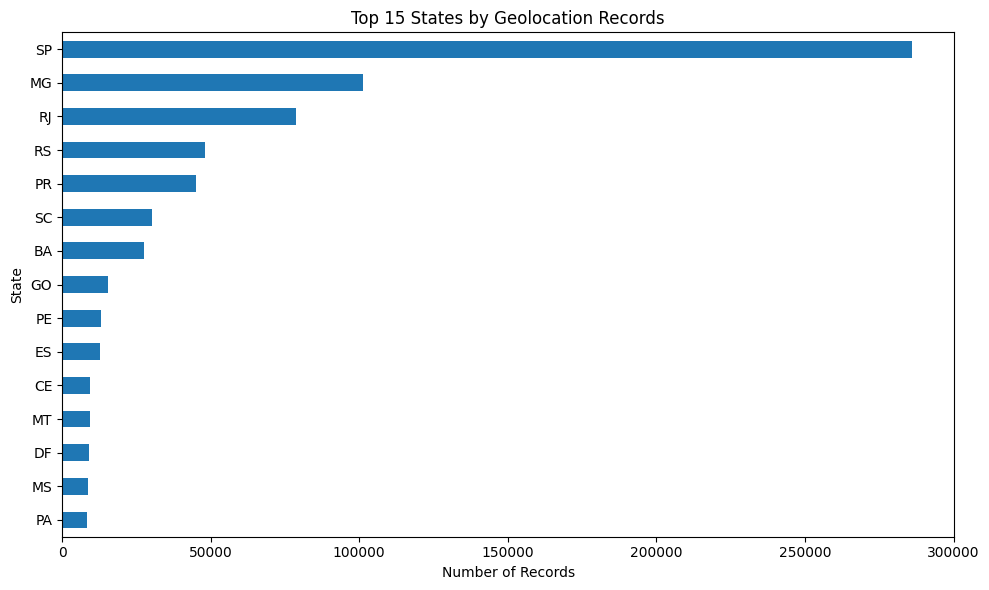

In [188]:
import matplotlib.pyplot as plt

state_counts = (
    geolocation["geolocation_state"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))
state_counts.sort_values().plot(kind="barh")

plt.title("Top 15 States by Geolocation Records")
plt.xlabel("Number of Records")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### 2. Geographic distribution

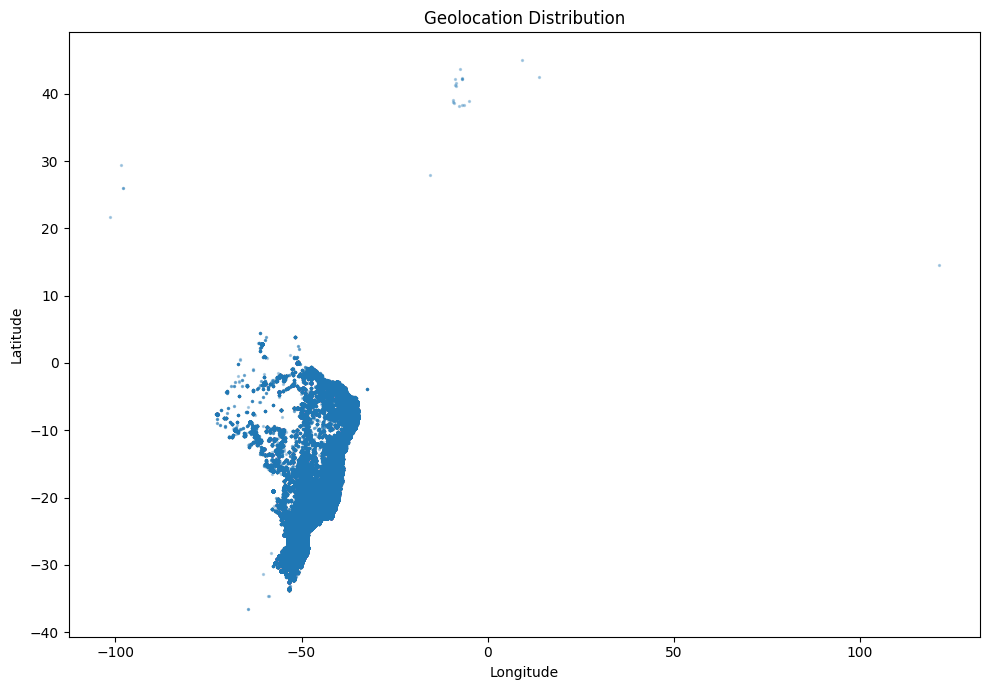

In [189]:
plt.figure(figsize=(10, 7))

plt.scatter(
    geolocation["geolocation_lng"],
    geolocation["geolocation_lat"],
    s=2,
    alpha=0.3
)

plt.title("Geolocation Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

### 3. Top cities

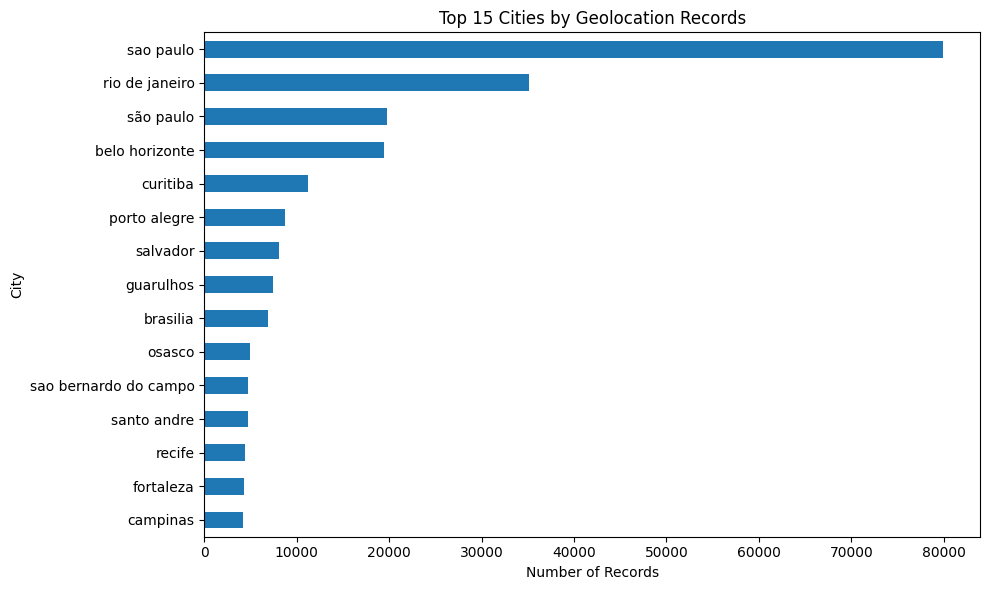

In [190]:
city_counts = (
    geolocation["geolocation_city"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

city_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Cities by Geolocation Records")
plt.xlabel("Number of Records")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## Order Reviews

In [194]:
print(reviews.shape)

print("=" * 60)


(99224, 7)


In [191]:
print(reviews.head())

print("=" * 60)

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

In [192]:
print(reviews.info())

print("=" * 60)
print(reviews.isnull().sum())

print("=" * 60)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [193]:
print("Duplicates:", reviews.duplicated().sum())

print("=" * 60)
print(reviews.nunique())

print("=" * 60)

Duplicates: 0
review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64


In [195]:
print(reviews.describe(include="all"))

                               review_id                          order_id  \
count                              99224                             99224   
unique                             98410                             98673   
top     08528f70f579f0c830189efc523d2182  df56136b8031ecd28e200bb18e6ddb2e   
freq                                   3                                 3   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        review_score review_comment_title review_comment_messag

In [196]:
# Convert date columns to datetime

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"],
    errors="coerce"
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"],
    errors="coerce"
)

print(reviews[
    ["review_creation_date", "review_answer_timestamp"]
].dtypes)

review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


In [197]:
print("Review score values:")
print(reviews["review_score"].value_counts().sort_index())

print("\nInvalid review scores:")
print(
    reviews[
        ~reviews["review_score"].between(1, 5)
    ][["review_id", "order_id", "review_score"]]
)

Review score values:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Invalid review scores:
Empty DataFrame
Columns: [review_id, order_id, review_score]
Index: []


In [198]:
review_id_counts = (
    reviews["review_id"]
    .value_counts()
)

print("Duplicated review_ids:")
print(
    review_id_counts[
        review_id_counts > 1
    ].head(20)
)

print(
    "\nNumber of duplicated review_ids:",
    (review_id_counts > 1).sum()
)

Duplicated review_ids:
review_id
08528f70f579f0c830189efc523d2182    3
c444278834184f72b1484dfe47de7f97    3
39b4603793c1c7f5f36d809b4a218664    3
44e9f871226d8a130de3fc39dfbdf0c5    3
1fb4ddc969e6bea80e38deec00393a6f    3
2d6ac45f859465b5c185274a1c929637    3
f4bb9d6dd4fb6dcc2298f0e7b17b8e1e    3
2172867fd5b1a55f98fe4608e1547b4b    3
32415bbf6e341d5d517080a796f79b5c    3
7b606b0d57b078384f0b58eac1d41d78    3
69a1068c3128a14994e3e422e4539e04    3
3415c9f764e478409e8e0660ae816dd2    3
4219a80ab469e3fc9901437b73da3f75    3
dbdf1ea31790c8ecfcc6750525661a9b    3
38821b5c496b678cf91acc34892805ad    3
0c76e7a547a531e7bf9f0b99cba071c1    3
4d0e6dd087008d1f992d25ef6e1f619f    3
9e25d6e3025e9b9a0fc7f03588d33e2b    3
308316408775d1600dad81bd3184556d    3
e44840754f12fad2b8646712121b349a    3
Name: count, dtype: int64

Number of duplicated review_ids: 789


In [199]:
duplicated_review_ids = review_id_counts[
    review_id_counts > 1
].index

duplicate_reviews = reviews[
    reviews["review_id"].isin(duplicated_review_ids)
].sort_values("review_id")

print(duplicate_reviews.head(30))

                              review_id                          order_id  \
46678  00130cbe1f9d422698c812ed8ded1919  dfcdfc43867d1c1381bfaf62d6b9c195   
29841  00130cbe1f9d422698c812ed8ded1919  04a28263e085d399c97ae49e0b477efa   
90677  0115633a9c298b6a98bcbe4eee75345f  78a4201f58af3463bdab842eea4bc801   
63193  0115633a9c298b6a98bcbe4eee75345f  0c9850b2c179c1ef60d2855e2751d1fa   
92876  0174caf0ee5964646040cd94e15ac95e  f93a732712407c02dce5dd5088d0f47b   
57280  0174caf0ee5964646040cd94e15ac95e  74db91e33b4e1fd865356c89a61abf1f   
54832  017808d29fd1f942d97e50184dfb4c13  8daaa9e99d60fbba579cc1c3e3bfae01   
99167  017808d29fd1f942d97e50184dfb4c13  b1461c8882153b5fe68307c46a506e39   
20621  0254bd905dc677a6078990aad3331a36  5bf226cf882c5bf4247f89a97c86f273   
96080  0254bd905dc677a6078990aad3331a36  331b367bdd766f3d1cf518777317b5d9   
89712  0288d42bef3dfe36930740c9588a570f  33d8795f04dd631f3480d7aaf90da3dc   
94851  0288d42bef3dfe36930740c9588a570f  f889a5a0b44adc29c5465b99395ac3c1   

In [200]:
order_review_counts = (
    reviews["order_id"]
    .value_counts()
)

print("Orders with multiple reviews:")
print(
    order_review_counts[
        order_review_counts > 1
    ].head(20)
)

print(
    "\nNumber of orders with multiple reviews:",
    (order_review_counts > 1).sum()
)

Orders with multiple reviews:
order_id
df56136b8031ecd28e200bb18e6ddb2e    3
c88b1d1b157a9999ce368f218a407141    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
029863af4b968de1e5d6a82782e662f5    2
29062384ce4975f78aeba6a496510386    2
bbf6a647ecc68aa5e79d2cd75ef44c68    2
7f13a20e25350f4a55fb2a7c9a2e8d88    2
aef2bc3845eb581cecce74b769d46c6a    2
0ed5043fe7d3f4f88353697330bbc020    2
3b132068223649635448d659e7826d12    2
824fa8179b9911d58831e0b09eedde13    2
8ef17147aad160f7780239dcf0acb400    2
dd73d93a25e576d8dae52c7c66b3becf    2
056bfadd41b8600ad5ecfef2ac132188    2
f299e3cfbddf9de401e1f1adf33cd788    2
1544b91291000836c72384f035436fbf    2
e832fe7f7808b5f981ee02746681d40e    2
e9e7ebde60b33ca371a24f94a52fb499    2
4d006fbdecd41058974d5d99f2d69650    2
Name: count, dtype: int64

Number of orders with multiple reviews: 547


In [201]:
reviews["review_response_time_hours"] = (
    reviews["review_answer_timestamp"]
    - reviews["review_creation_date"]
).dt.total_seconds() / 3600

print(
    reviews["review_response_time_hours"].describe()
)

count    99224.000000
mean        75.575842
std        237.361183
min          2.141389
25%         24.116875
50%         40.198750
75%         74.485556
max      12448.781111
Name: review_response_time_hours, dtype: float64


In [203]:
print(
    "Negative response times:",
    (reviews["review_response_time_hours"] < 0).sum()
)

Negative response times: 0


### Review Score Distribution

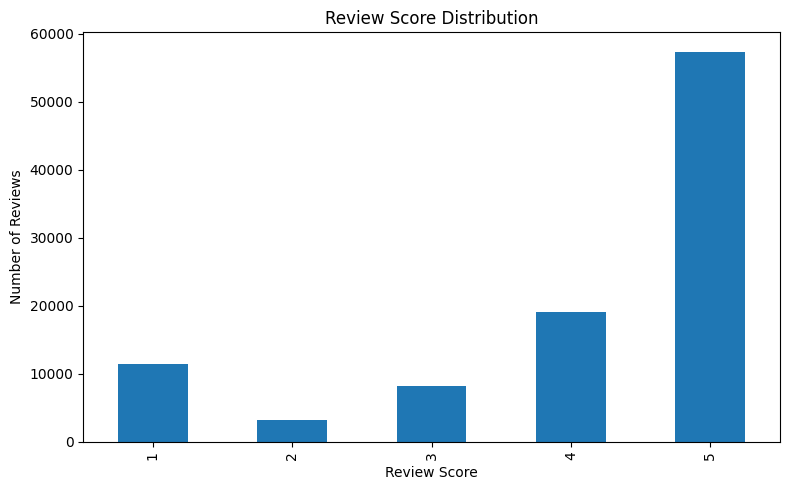

In [204]:
import matplotlib.pyplot as plt

score_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

score_counts.plot(kind="bar")

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

### Rating Percentage

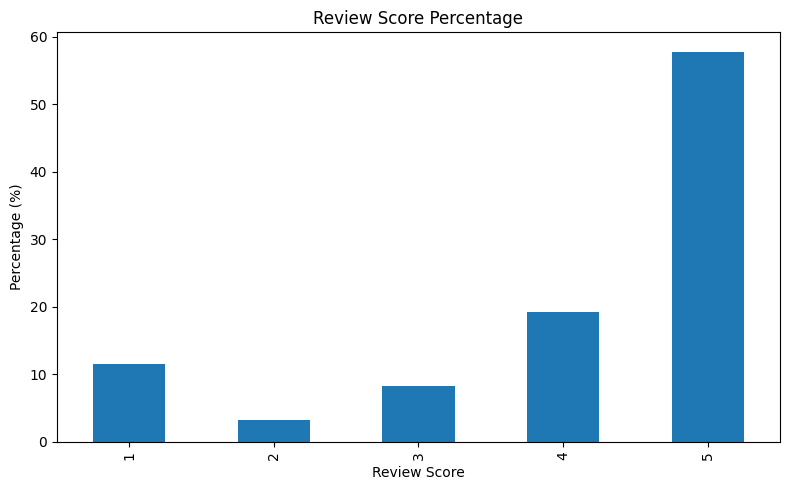

In [205]:
score_percentage = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(8, 5))

score_percentage.plot(kind="bar")

plt.title("Review Score Percentage")
plt.xlabel("Review Score")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

### Reviews over time

C:\Users\hp\AppData\Local\Temp\ipykernel_12672\278962673.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


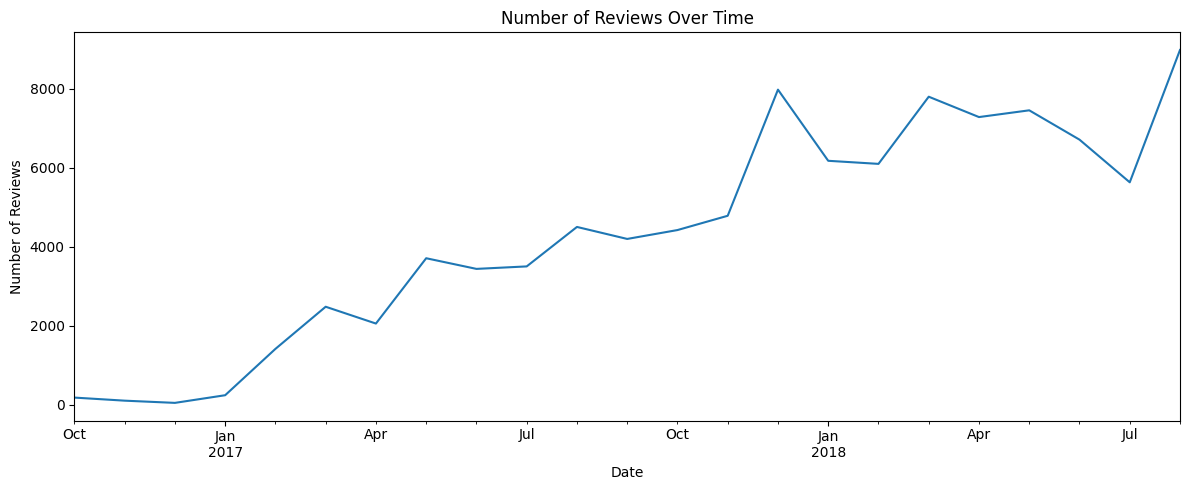

In [206]:
reviews_by_date = (
    reviews
    .set_index("review_creation_date")
    .resample("M")
    .size()
)

plt.figure(figsize=(12, 5))

reviews_by_date.plot()

plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

### Response time

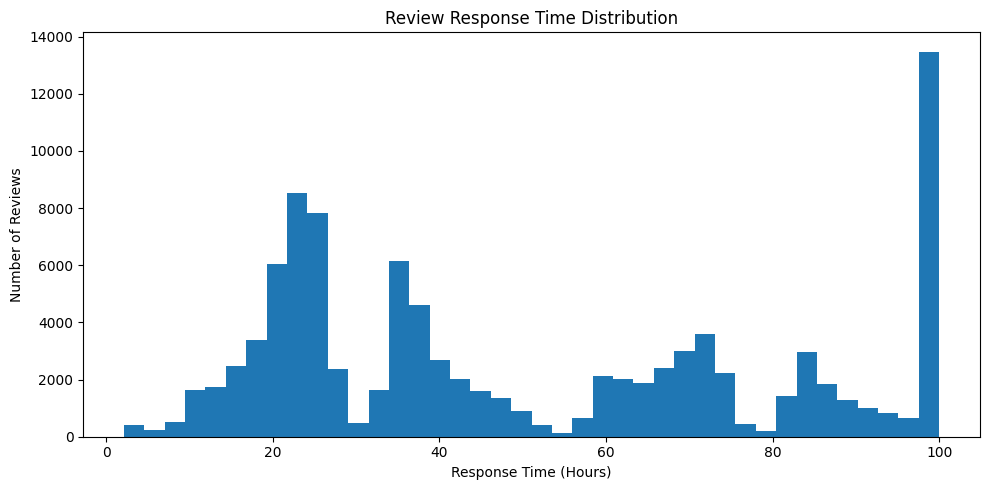

In [207]:
plt.figure(figsize=(10, 5))

reviews["review_response_time_hours"].clip(
    upper=100
).plot(kind="hist", bins=40)

plt.title("Review Response Time Distribution")
plt.xlabel("Response Time (Hours)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [211]:
print("=" * 60)
print("FINAL REVIEW CHECK")
print("=" * 60)

print("Shape:", reviews.shape)

print("\nExact duplicates:")
print(reviews.duplicated().sum())

print("\nMissing values:")
print(reviews.isnull().sum())


FINAL REVIEW CHECK
Shape: (99224, 8)

Exact duplicates:
0

Missing values:
review_id                         0
order_id                          0
review_score                      0
review_comment_title          87656
review_comment_message        58247
review_creation_date              0
review_answer_timestamp           0
review_response_time_hours        0
dtype: int64


In [209]:
print("\nData types:")
print(reviews.dtypes)


Data types:
review_id                             object
order_id                              object
review_score                           int64
review_comment_title                  object
review_comment_message                object
review_creation_date          datetime64[ns]
review_answer_timestamp       datetime64[ns]
review_response_time_hours           float64
dtype: object


In [210]:
print("\nReview scores:")
print(reviews["review_score"].value_counts().sort_index())


Review scores:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


### category_translation table

In [217]:
print(category_translation.shape)
print("="*60)

(71, 2)


In [213]:
print(category_translation.head())
print("="*60)

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


In [214]:
print(category_translation.info())
print("="*60)
print(category_translation.isnull().sum())
print("="*60)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None
product_category_name            0
product_category_name_english    0
dtype: int64


In [215]:
print("Duplicates:", category_translation.duplicated().sum())
print("="*60)
print(category_translation.nunique())
print("="*60)

Duplicates: 0
product_category_name            71
product_category_name_english    71
dtype: int64


In [216]:
print(category_translation.describe(include="all"))

       product_category_name product_category_name_english
count                     71                            71
unique                    71                            71
top             beleza_saude                 health_beauty
freq                       1                             1


## ML Dataset Preparation

In [218]:
# Copies for ML preparation

orders_ml = orders.copy()
order_items_ml = order_items.copy()
products_ml = products.copy()
customers_ml = customers.copy()
sellers_ml = sellers.copy()
payments_ml = payments.copy()
category_translation_ml = category_translation.copy()

In [219]:
print("Orders:", orders_ml.shape)
print("Order items:", order_items_ml.shape)
print("Products:", products_ml.shape)
print("Customers:", customers_ml.shape)
print("Sellers:", sellers_ml.shape)
print("Payments:", payments_ml.shape)
print("Category translation:", category_translation_ml.shape)

Orders: (99441, 8)
Order items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Sellers: (3095, 4)
Payments: (103886, 6)
Category translation: (71, 2)


In [220]:
print(orders.columns.tolist())
print(orders.head())
print(orders.shape)

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:2

In [221]:
# Convert order date columns to datetime

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_ml[col] = pd.to_datetime(orders_ml[col], errors='coerce')

orders_ml[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [222]:
print(orders_ml[date_cols].isnull().sum())

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [223]:
orders_ml['late_delivery'] = (
    orders_ml['order_delivered_customer_date'] >
    orders_ml['order_estimated_delivery_date']
).astype(int)

print(orders_ml['late_delivery'].value_counts())
print(orders_ml['late_delivery'].value_counts(normalize=True) * 100)

late_delivery
0    91614
1     7827
Name: count, dtype: int64
late_delivery
0    92.129001
1     7.870999
Name: proportion, dtype: float64


In [224]:
orders_ml[
    [
        'order_id',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'late_delivery'
    ]
].head(10)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,0
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-26 10:57:55,2017-08-01,0
6,136cce7faa42fdb2cefd53fdc79a6098,NaT,2017-05-09,0
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-26 12:55:51,2017-06-07,0
8,76c6e866289321a7c93b82b54852dc33,2017-02-02 14:08:10,2017-03-06,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-08-16 17:14:30,2017-08-23,0


In [225]:
# Orders where actual delivery date is missing

missing_delivery = orders_ml[
    orders_ml['order_delivered_customer_date'].isna()
]

print("Orders with missing delivery date:", len(missing_delivery))

print("\nOrder status distribution:")
print(missing_delivery['order_status'].value_counts())

Orders with missing delivery date: 2965

Order status distribution:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [226]:
# Keep only orders with a known delivery outcome

ml_orders = orders_ml[
    orders_ml['order_delivered_customer_date'].notna()
].copy()

print("ML orders shape:", ml_orders.shape)

print("\nTarget distribution:")
print(ml_orders['late_delivery'].value_counts())

print("\nTarget percentage:")
print(
    ml_orders['late_delivery']
    .value_counts(normalize=True)
    .mul(100)
)

ML orders shape: (96476, 9)

Target distribution:
late_delivery
0    88649
1     7827
Name: count, dtype: int64

Target percentage:
late_delivery
0    91.887101
1     8.112899
Name: proportion, dtype: float64


In [227]:
print(
    ml_orders.groupby('late_delivery')[
        'order_delivered_customer_date'
    ].count()
)

late_delivery
0    88649
1     7827
Name: order_delivered_customer_date, dtype: int64


In [229]:
orders['late_delivery'] = (
    orders['order_delivered_customer_date'] >
    orders['order_estimated_delivery_date']
).astype(int)

# Missing delivery date should NOT be considered late
orders.loc[
    orders['order_delivered_customer_date'].isna(),
    'late_delivery'
] = 0

print(orders['late_delivery'].value_counts())
print((orders['late_delivery'].value_counts(normalize=True) * 100).round(2))

late_delivery
0    91614
1     7827
Name: count, dtype: int64
late_delivery
0    92.13
1     7.87
Name: proportion, dtype: float64


In [231]:
print("=" * 60)
print("ORDERS EDA")
print("=" * 60)

# 1. Order status distribution
print("\n1. ORDER STATUS DISTRIBUTION")
print(orders['order_status'].value_counts())
print("\nPercentage:")
print((orders['order_status'].value_counts(normalize=True) * 100).round(2))


# 2. Orders by purchase year
print("\n2. ORDERS BY YEAR")
print(orders['order_purchase_timestamp'].dt.year.value_counts().sort_index())


# 3. Orders by month
print("\n3. ORDERS BY MONTH")
print(orders['order_purchase_timestamp'].dt.month.value_counts().sort_index())


# 4. Orders by weekday
print("\n4. ORDERS BY WEEKDAY")
print(
    orders['order_purchase_timestamp']
    .dt.day_name()
    .value_counts()
)


# 5. Purchase hour
print("\n5. ORDERS BY HOUR")
print(
    orders['order_purchase_timestamp']
    .dt.hour
    .value_counts()
    .sort_index()
)


# 6. Approval time
orders['approval_time_hours'] = (
    orders['order_approved_at'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

print("\n6. APPROVAL TIME SUMMARY")
print(orders['approval_time_hours'].describe())


# 7. Delivery time
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

print("\n7. DELIVERY TIME SUMMARY")
print(orders['delivery_time_days'].describe())


# 8. Carrier delivery time
orders['carrier_time_days'] = (
    orders['order_delivered_carrier_date'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

print("\n8. CARRIER TIME SUMMARY")
print(orders['carrier_time_days'].describe())


# 9. Estimated delivery gap
orders['delivery_estimation_gap_days'] = (
    orders['order_estimated_delivery_date'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

print("\n9. ESTIMATED DELIVERY TIME SUMMARY")
print(orders['delivery_estimation_gap_days'].describe())




ORDERS EDA

1. ORDER STATUS DISTRIBUTION
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Percentage:
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

2. ORDERS BY YEAR
order_purchase_timestamp
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

3. ORDERS BY MONTH
order_purchase_timestamp
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: count, dtype: int64

4. ORDERS BY WEEKDAY
order_purchase_timestamp
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Sunday       11960
Saturday     10887
Name: count, dtype

In [232]:
# 10. Late delivery by order status
print("\n10. LATE DELIVERY BY ORDER STATUS")
print(
    pd.crosstab(
        orders['order_status'],
        orders['late_delivery'],
        normalize='index'
    ).round(4) * 100
)


# 11. Late delivery by month
print("\n11. LATE DELIVERY BY MONTH")
print(
    pd.crosstab(
        orders['order_purchase_timestamp'].dt.month,
        orders['late_delivery'],
        normalize='index'
    ).round(4) * 100
)


# 12. Late delivery by year
print("\n12. LATE DELIVERY BY YEAR")
print(
    pd.crosstab(
        orders['order_purchase_timestamp'].dt.year,
        orders['late_delivery'],
        normalize='index'
    ).round(4) * 100
)


# 13. Correlation between numerical time features
print("\n13. NUMERICAL CORRELATION")
print(
    orders[
        [
            'approval_time_hours',
            'delivery_time_days',
            'carrier_time_days',
            'delivery_estimation_gap_days',
            'late_delivery'
        ]
    ].corr()['late_delivery'].sort_values(ascending=False)
)


10. LATE DELIVERY BY ORDER STATUS
late_delivery       0     1
order_status               
approved       100.00  0.00
canceled        99.84  0.16
created        100.00  0.00
delivered       91.89  8.11
invoiced       100.00  0.00
processing     100.00  0.00
shipped        100.00  0.00
unavailable    100.00  0.00

11. LATE DELIVERY BY MONTH
late_delivery                 0      1
order_purchase_timestamp              
1                         93.96   6.04
2                         87.05  12.95
3                         83.44  16.56
4                         94.20   5.80
5                         93.53   6.47
6                         97.83   2.17
7                         96.04   3.96
8                         92.63   7.37
9                         94.96   5.04
10                        95.16   4.84
11                        86.17  13.83
12                        91.86   8.14

12. LATE DELIVERY BY YEAR
late_delivery                 0     1
order_purchase_timestamp             
2016    

In [234]:
print("=" * 60)
print("INVALID CARRIER TIME")
print("=" * 60)

invalid_carrier = orders[
    orders['carrier_time_days'] < 0
][[
    'order_id',
    'order_purchase_timestamp',
    'order_delivered_carrier_date',
    'carrier_time_days',
    'order_status'
]]

print("Number of negative carrier times:", len(invalid_carrier))
print(invalid_carrier)

INVALID CARRIER TIME
Number of negative carrier times: 166
                               order_id order_purchase_timestamp  \
615    b9afddbdcfadc9a87b41a83271c3e888      2018-08-16 13:50:48   
1111   ad133696906f6a78826daa0911b7daec      2018-06-15 15:41:22   
1329   74e033208dc13a7b8127eb8e73d09b76      2018-05-02 10:48:44   
1372   a6b58794fd2ba533359a76c08df576e3      2018-05-14 15:18:23   
1864   5792e0b1c8c8a2bf53af468c9a422c88      2018-07-26 13:25:14   
...                                 ...                      ...   
98172  f7780ea2807db31691e83f0013294035      2018-07-30 15:22:15   
98430  d7646ffe8fdd9e7d9557f9f7cbf04530      2018-05-04 14:50:37   
98672  5ded8a3706eabd813685534724f066de      2018-07-18 08:46:52   
98780  d10046876c7d9f01613da59ffa6cb07f      2018-07-18 16:14:16   
99230  78008d03bd8ef7fcf1568728b316553c      2018-07-03 13:11:13   

      order_delivered_carrier_date  carrier_time_days order_status  
615            2018-08-16 13:27:00          -0.016528  

In [235]:
print("=" * 60)
print("INVALID APPROVAL TIME")
print("=" * 60)

invalid_approval = orders[
    orders['approval_time_hours'] < 0
][[
    'order_id',
    'order_purchase_timestamp',
    'order_approved_at',
    'approval_time_hours',
    'order_status'
]]

print("Number of negative approval times:", len(invalid_approval))
print(invalid_approval)

INVALID APPROVAL TIME
Number of negative approval times: 0
Empty DataFrame
Columns: [order_id, order_purchase_timestamp, order_approved_at, approval_time_hours, order_status]
Index: []


In [236]:
# Fix invalid carrier time values
orders.loc[
    orders['carrier_time_days'] < 0,
    'carrier_time_days'
] = np.nan

print("Negative carrier times after cleaning:",
      (orders['carrier_time_days'] < 0).sum())

print("Missing carrier_time_days:",
      orders['carrier_time_days'].isna().sum())

Negative carrier times after cleaning: 0
Missing carrier_time_days: 1949


In [237]:
print("=" * 60)
print("FINAL ORDERS CHECK")
print("=" * 60)

print("Shape:", orders.shape)

print("\nDuplicates:")
print(orders.duplicated().sum())

print("\nMissing values:")
print(orders.isna().sum())

print("\nData types:")
print(orders.dtypes)

print("\nOrder status:")
print(orders['order_status'].value_counts())

print("\nLate delivery:")
print(orders['late_delivery'].value_counts())

print("\nLate delivery percentage:")
print(
    (orders['late_delivery'].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nNegative approval times:")
print((orders['approval_time_hours'] < 0).sum())

print("\nNegative carrier times:")
print((orders['carrier_time_days'] < 0).sum())

print("\nDelivery time summary:")
print(orders['delivery_time_days'].describe())

FINAL ORDERS CHECK
Shape: (99441, 13)

Duplicates:
0

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
approval_time_hours               160
delivery_time_days               2965
carrier_time_days                1949
delivery_estimation_gap_days        0
late_delivery                       0
dtype: int64

Data types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
approval_time_hours       

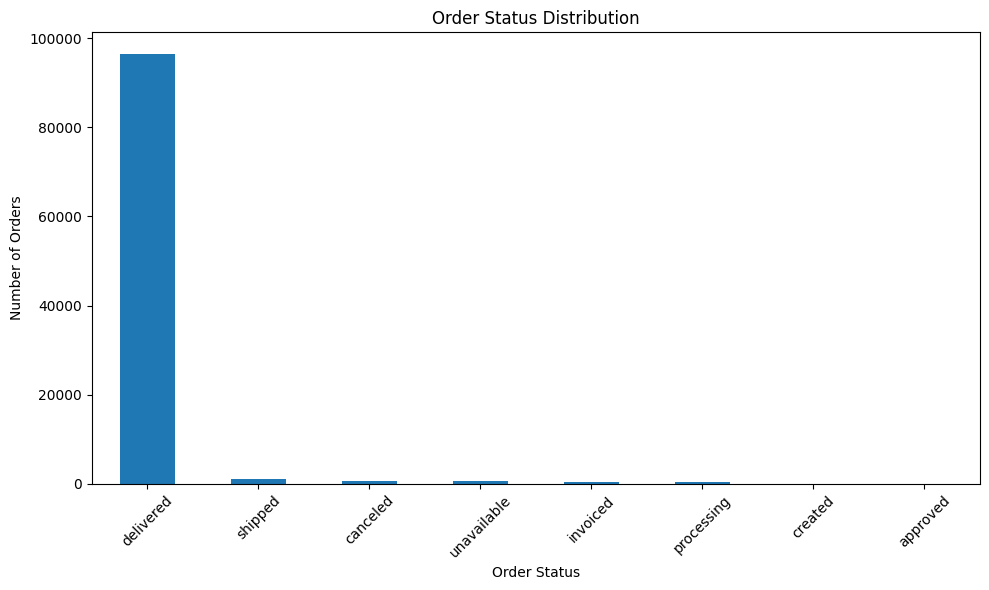

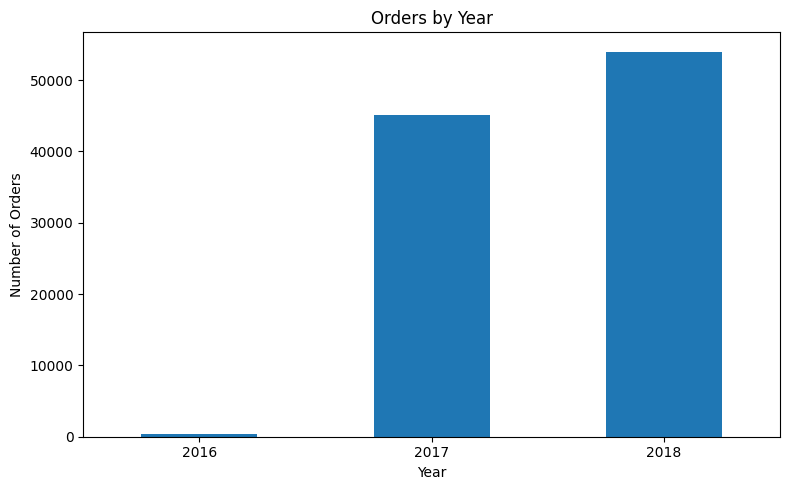

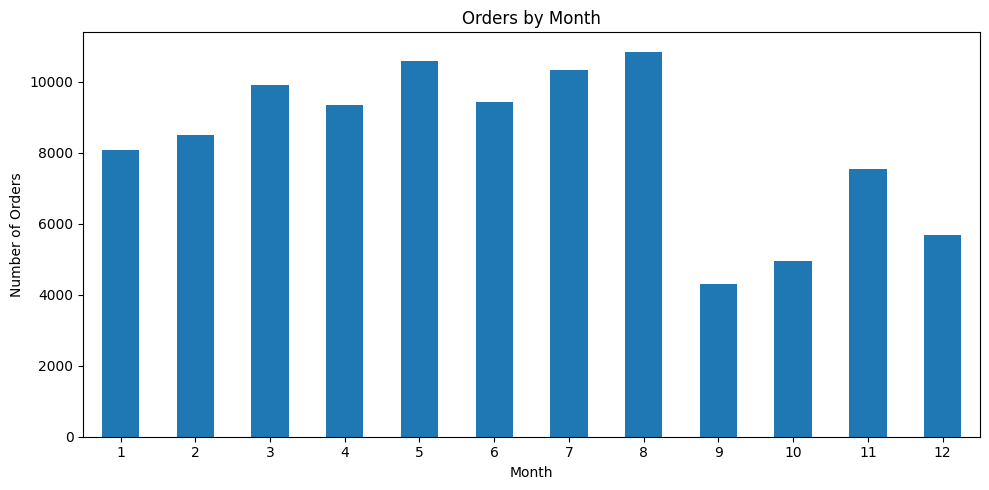

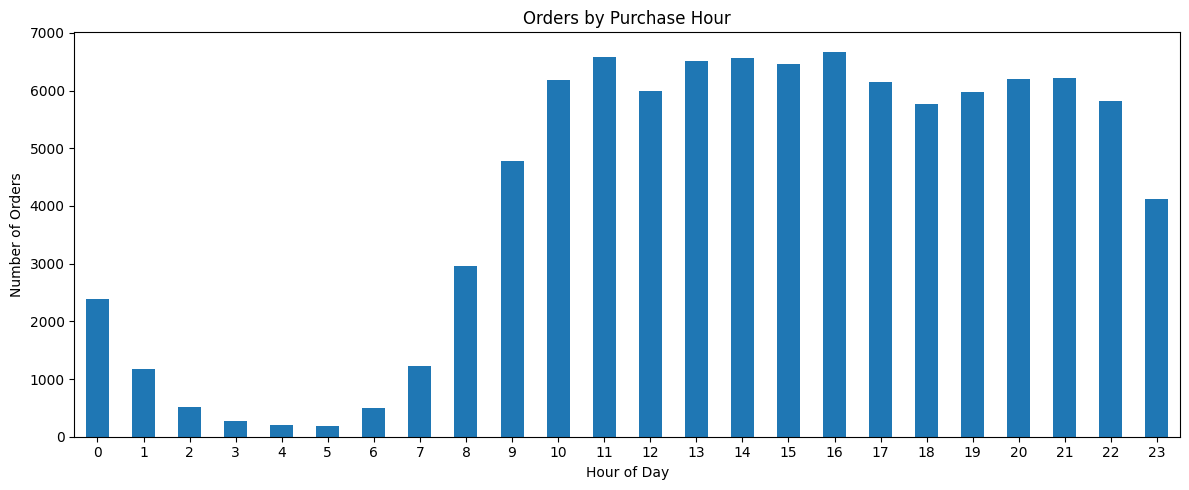

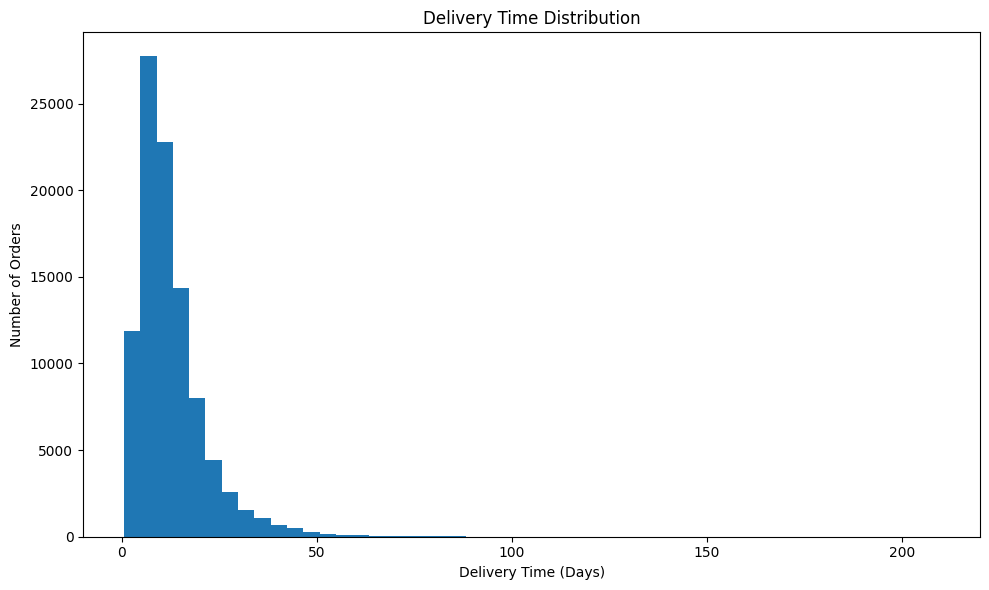

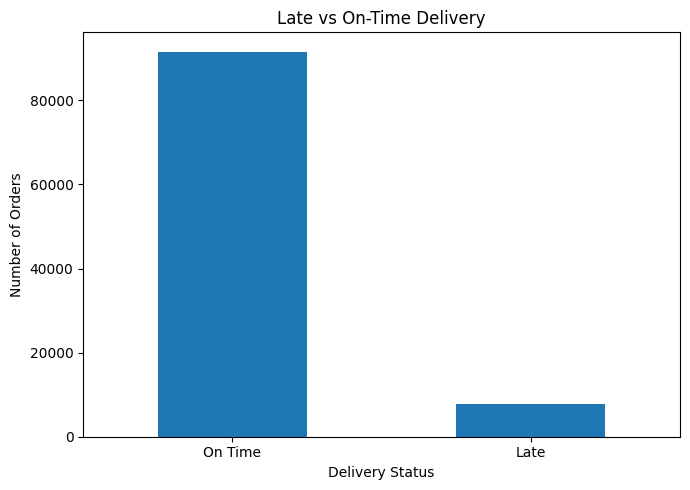

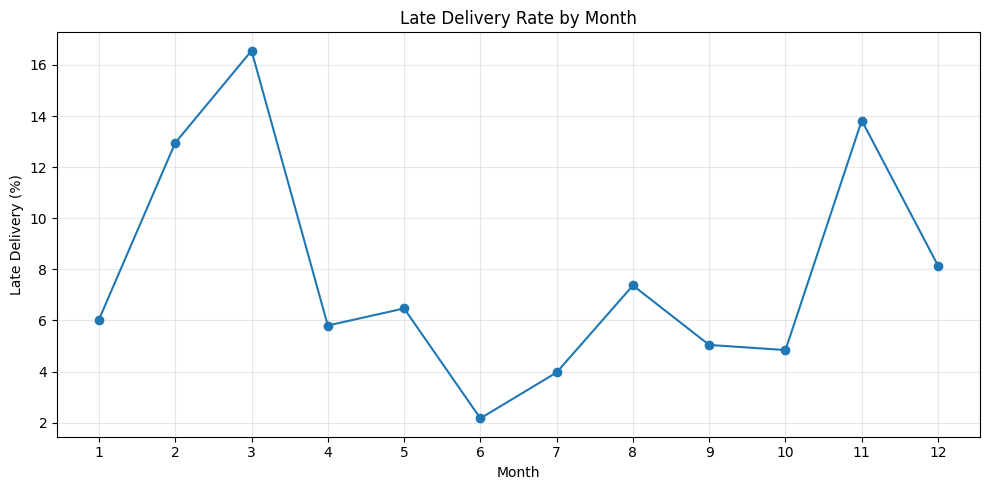

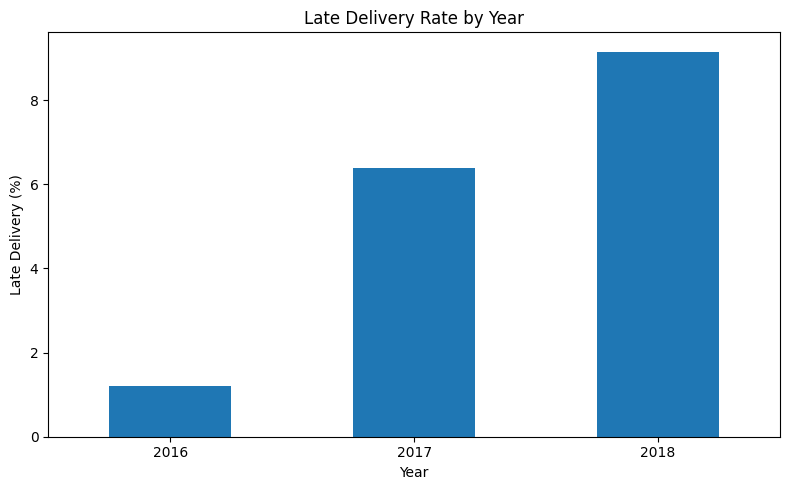

In [238]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# ORDERS EDA - CHARTS
# ============================================================

# 1. ORDER STATUS DISTRIBUTION
plt.figure(figsize=(10, 6))

orders['order_status'].value_counts().plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. ORDERS BY YEAR
plt.figure(figsize=(8, 5))

orders['order_purchase_timestamp'].dt.year.value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Orders by Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. ORDERS BY MONTH
monthly_orders = (
    orders['order_purchase_timestamp']
    .dt.month
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

monthly_orders.plot(kind='bar')

plt.title('Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 4. ORDERS BY HOUR
hourly_orders = (
    orders['order_purchase_timestamp']
    .dt.hour
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

hourly_orders.plot(kind='bar')

plt.title('Orders by Purchase Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 5. DELIVERY TIME DISTRIBUTION
plt.figure(figsize=(10, 6))

orders['delivery_time_days'].dropna().plot(
    kind='hist',
    bins=50
)

plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


# 6. LATE VS ON-TIME DELIVERY
late_counts = orders['late_delivery'].map({
    0: 'On Time',
    1: 'Late'
}).value_counts()

plt.figure(figsize=(7, 5))

late_counts.plot(kind='bar')

plt.title('Late vs On-Time Delivery')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 7. LATE DELIVERY % BY MONTH
monthly_late = (
    orders.groupby(
        orders['order_purchase_timestamp'].dt.month
    )['late_delivery']
    .mean() * 100
)

plt.figure(figsize=(10, 5))

monthly_late.plot(kind='line', marker='o')

plt.title('Late Delivery Rate by Month')
plt.xlabel('Month')
plt.ylabel('Late Delivery (%)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 8. LATE DELIVERY % BY YEAR
yearly_late = (
    orders.groupby(
        orders['order_purchase_timestamp'].dt.year
    )['late_delivery']
    .mean() * 100
)

plt.figure(figsize=(8, 5))

yearly_late.plot(kind='bar')

plt.title('Late Delivery Rate by Year')
plt.xlabel('Year')
plt.ylabel('Late Delivery (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Merged Dataset + Feature Engineering

In [239]:
# ============================================================
# STEP 1 — CHECK MULTIPLE ROWS PER ORDER
# ============================================================

print("=" * 60)
print("ORDER ITEMS PER ORDER")
print("=" * 60)

items_per_order = order_items.groupby('order_id').size()

print(items_per_order.describe())
print("\nOrders with multiple items:")
print((items_per_order > 1).sum())


print("\n" + "=" * 60)
print("PAYMENTS PER ORDER")
print("=" * 60)

payments_per_order = payments.groupby('order_id').size()

print(payments_per_order.describe())
print("\nOrders with multiple payments:")
print((payments_per_order > 1).sum())

ORDER ITEMS PER ORDER
count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

Orders with multiple items:
9803

PAYMENTS PER ORDER
count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

Orders with multiple payments:
2961


In [240]:
# ============================================================
# STEP 2 — AGGREGATE ORDER ITEMS
# ============================================================

order_items_agg = (
    order_items
    .groupby('order_id')
    .agg(
        total_items=('order_item_id', 'count'),
        total_product_value=('price', 'sum'),
        total_freight_value=('freight_value', 'sum'),
        unique_products=('product_id', 'nunique'),
        unique_sellers=('seller_id', 'nunique')
    )
    .reset_index()
)

print("Order items aggregated shape:", order_items_agg.shape)
print(order_items_agg.head())


# ============================================================
# STEP 3 — AGGREGATE PAYMENTS
# ============================================================

payments_agg = (
    payments
    .groupby('order_id')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        payment_count=('payment_sequential', 'count'),
        max_installments=('payment_installments_clean', 'max')
    )
    .reset_index()
)

print("\nPayments aggregated shape:", payments_agg.shape)
print(payments_agg.head())

Order items aggregated shape: (98666, 6)
                           order_id  total_items  total_product_value  \
0  00010242fe8c5a6d1ba2dd792cb16214            1                58.90   
1  00018f77f2f0320c557190d7a144bdd3            1               239.90   
2  000229ec398224ef6ca0657da4fc703e            1               199.00   
3  00024acbcdf0a6daa1e931b038114c75            1                12.99   
4  00042b26cf59d7ce69dfabb4e55b4fd9            1               199.90   

   total_freight_value  unique_products  unique_sellers  
0                13.29                1               1  
1                19.93                1               1  
2                17.87                1               1  
3                12.79                1               1  
4                18.14                1               1  

Payments aggregated shape: (99440, 4)
                           order_id  total_payment_value  payment_count  \
0  00010242fe8c5a6d1ba2dd792cb16214                72.19  

In [241]:
# ============================================================
# STEP 4 — CREATE MASTER DATASET
# ============================================================

master = orders.merge(
    order_items_agg,
    on='order_id',
    how='left'
)

master = master.merge(
    payments_agg,
    on='order_id',
    how='left'
)

print("=" * 60)
print("MASTER DATASET")
print("=" * 60)

print("Shape:", master.shape)
print("\nColumns:")
print(master.columns.tolist())

print("\nMissing values:")
print(master.isna().sum())

MASTER DATASET
Shape: (99441, 21)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'approval_time_hours', 'delivery_time_days', 'carrier_time_days', 'delivery_estimation_gap_days', 'late_delivery', 'total_items', 'total_product_value', 'total_freight_value', 'unique_products', 'unique_sellers', 'total_payment_value', 'payment_count', 'max_installments']

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
approval_time_hours               160
delivery_time_days               2965
carrier_time_days                1949
delivery_estimation_gap_days        0
late_delivery      

In [260]:
# ============================================================
# MASTER DATASET EDA
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("MASTER DATASET EDA")
print("=" * 60)

# ------------------------------------------------------------
# 1. BASIC OVERVIEW
# ------------------------------------------------------------

print("\n1. MASTER DATASET SHAPE")
print(master.shape)

print("\n2. NUMERICAL SUMMARY")
print(
    master[
        [
            'total_items',
            'total_product_value',
            'total_freight_value',
            'unique_products',
            'unique_sellers',
            'total_payment_value',
            'payment_count',
            'max_installments',
            'late_delivery'
        ]
    ].describe().round(2)
)


MASTER DATASET EDA

1. MASTER DATASET SHAPE
(99441, 21)

2. NUMERICAL SUMMARY
       total_items  total_product_value  total_freight_value  unique_products  \
count     98666.00             98666.00             98666.00         98666.00   
mean          1.14               137.75                22.82             1.04   
std           0.54               210.65                21.65             0.23   
min           1.00                 0.85                 0.00             1.00   
25%           1.00                45.90                13.85             1.00   
50%           1.00                86.90                17.17             1.00   
75%           1.00               149.90                24.04             1.00   
max          21.00             13440.00              1794.96             8.00   

       unique_sellers  total_payment_value  payment_count  max_installments  \
count        98666.00             99440.00       99440.00          99440.00   
mean             1.01             

In [261]:
# ------------------------------------------------------------
# 2. MISSING VALUES
# ------------------------------------------------------------

print("\n3. MISSING VALUES")
missing = master.isnull().sum()
print(missing[missing > 0])



3. MISSING VALUES
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
approval_time_hours               160
delivery_time_days               2965
carrier_time_days                1949
total_items                       775
total_product_value               775
total_freight_value               775
unique_products                   775
unique_sellers                    775
total_payment_value                 1
payment_count                       1
max_installments                    1
dtype: int64


In [262]:
# ------------------------------------------------------------
# 3. ORDER SIZE
# ------------------------------------------------------------

print("\n4. ORDER ITEMS DISTRIBUTION")
print(master['total_items'].value_counts().sort_index().head(15))

print("\nOrders with multiple items:")
print((master['total_items'] > 1).sum())





4. ORDER ITEMS DISTRIBUTION
total_items
1.0     88863
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
9.0         3
10.0        8
11.0        4
12.0        5
13.0        1
14.0        2
15.0        2
Name: count, dtype: int64

Orders with multiple items:
9803


In [263]:
# ------------------------------------------------------------
# 4. BUSINESS METRICS
# ------------------------------------------------------------

print("\n5. BUSINESS METRICS")

metrics = [
    'total_product_value',
    'total_freight_value',
    'total_payment_value',
    'payment_count',
    'max_installments'
]

for col in metrics:
    print(f"\n{col}")
    print(master[col].describe().round(2))






5. BUSINESS METRICS

total_product_value
count    98666.00
mean       137.75
std        210.65
min          0.85
25%         45.90
50%         86.90
75%        149.90
max      13440.00
Name: total_product_value, dtype: float64

total_freight_value
count    98666.00
mean        22.82
std         21.65
min          0.00
25%         13.85
50%         17.17
75%         24.04
max       1794.96
Name: total_freight_value, dtype: float64

total_payment_value
count    99440.00
mean       160.99
std        221.95
min          0.00
25%         62.01
50%        105.29
75%        176.97
max      13664.08
Name: total_payment_value, dtype: float64

payment_count
count    99440.00
mean         1.04
std          0.38
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         29.00
Name: payment_count, dtype: float64

max_installments
count    99440.00
mean         2.93
std          2.72
min          1.00
25%          1.00
50%          2.00
75%          4.00
max         24.00
N

In [264]:
# ------------------------------------------------------------
# 5. LATE DELIVERY VS ORDER SIZE
# ------------------------------------------------------------

print("\n6. LATE DELIVERY BY NUMBER OF ITEMS")

print(
    master.groupby('late_delivery')['total_items']
    .agg(['count', 'mean', 'median'])
    .round(2)
)


6. LATE DELIVERY BY NUMBER OF ITEMS
               count  mean  median
late_delivery                     
0              90839  1.14     1.0
1               7827  1.11     1.0


In [265]:
# ------------------------------------------------------------
# 6. LATE DELIVERY VS PRODUCT VALUE
# ------------------------------------------------------------

print("\n7. LATE DELIVERY BY PRODUCT VALUE")

print(
    master.groupby('late_delivery')['total_product_value']
    .agg(['count', 'mean', 'median'])
    .round(2)
)


7. LATE DELIVERY BY PRODUCT VALUE
               count    mean  median
late_delivery                       
0              90839  136.87    85.9
1               7827  148.07    89.9


In [266]:
# ------------------------------------------------------------
# 7. LATE DELIVERY VS FREIGHT
# ------------------------------------------------------------

print("\n8. LATE DELIVERY BY FREIGHT")

print(
    master.groupby('late_delivery')['total_freight_value']
    .agg(['count', 'mean', 'median'])
    .round(2)
)

# ------------------------------------------------------------
# 8. LATE DELIVERY VS SELLERS
# ------------------------------------------------------------

print("\n9. LATE DELIVERY BY NUMBER OF SELLERS")

print(
    master.groupby('late_delivery')['unique_sellers']
    .agg(['count', 'mean', 'median'])
    .round(2)
)

# ------------------------------------------------------------
# 9. LATE DELIVERY VS PAYMENTS
# ------------------------------------------------------------

print("\n10. LATE DELIVERY BY PAYMENT COUNT")

print(
    master.groupby('late_delivery')['payment_count']
    .agg(['count', 'mean', 'median'])
    .round(2)
)



8. LATE DELIVERY BY FREIGHT
               count   mean  median
late_delivery                      
0              90839  22.67   17.07
1               7827  24.62   18.05

9. LATE DELIVERY BY NUMBER OF SELLERS
               count  mean  median
late_delivery                     
0              90839  1.01     1.0
1               7827  1.00     1.0

10. LATE DELIVERY BY PAYMENT COUNT
               count  mean  median
late_delivery                     
0              91614  1.05     1.0
1               7826  1.04     1.0


In [267]:
# ------------------------------------------------------------
# 10. LATE DELIVERY VS INSTALLMENTS
# ------------------------------------------------------------

print("\n11. LATE DELIVERY BY INSTALLMENTS")

print(
    master.groupby('late_delivery')['max_installments']
    .agg(['count', 'mean', 'median'])
    .round(2)
)

# ------------------------------------------------------------
# 11. CORRELATION WITH TARGET
# ------------------------------------------------------------

print("\n12. CORRELATION WITH LATE DELIVERY")

corr_cols = [
    'total_items',
    'total_product_value',
    'total_freight_value',
    'unique_products',
    'unique_sellers',
    'total_payment_value',
    'payment_count',
    'max_installments',
    'late_delivery'
]

print(
    master[corr_cols]
    .corr()['late_delivery']
    .sort_values(ascending=False)
    .round(3)
)




11. LATE DELIVERY BY INSTALLMENTS
               count  mean  median
late_delivery                     
0              91614  2.92     2.0
1               7826  3.01     2.0

12. CORRELATION WITH LATE DELIVERY
late_delivery          1.000
total_freight_value    0.024
total_payment_value    0.015
total_product_value    0.014
max_installments       0.009
payment_count         -0.005
total_items           -0.015
unique_products       -0.021
unique_sellers        -0.027
Name: late_delivery, dtype: float64


In [268]:
# ------------------------------------------------------------
# 12. STATUS VS BUSINESS METRICS
# ------------------------------------------------------------

print("\n13. ORDER STATUS VS BUSINESS METRICS")

print(
    master.groupby('order_status')[
        [
            'total_items',
            'total_product_value',
            'total_freight_value',
            'total_payment_value'
        ]
    ]
    .mean()
    .round(2)
)

print("\n" + "=" * 60)
print("MASTER EDA FINISHED")
print("=" * 60)


13. ORDER STATUS VS BUSINESS METRICS
              total_items  total_product_value  total_freight_value  \
order_status                                                          
approved             1.50               104.80                15.74   
canceled             1.18               206.58                23.10   
created               NaN                  NaN                  NaN   
delivered            1.14               137.04                22.79   
invoiced             1.15               197.20                23.92   
processing           1.19               200.79                29.75   
shipped              1.07               136.28                23.87   
unavailable          1.17               334.62                22.13   

              total_payment_value  
order_status                       
approved                   120.54  
canceled                   229.21  
created                    137.62  
delivered                  159.86  
invoiced                   220.18  

In [274]:
import os

# ==========================================
# SAVE CLEANED DATASETS
# ==========================================

cleaned_path = r"D:\Hivia\Task 1\cleaned_data"

os.makedirs(cleaned_path, exist_ok=True)

cleaned_tables = {
    "customers_clean": customers,
    "geolocation_clean": geolocation,
    "order_items_clean": order_items,
    "payments_clean": payments,
    "reviews_clean": reviews,
    "orders_clean": orders,
    "products_clean": products,
    "sellers_clean": sellers,
    "category_translation_clean": category_translation
}

for name, df in cleaned_tables.items():
    file_path = os.path.join(cleaned_path, f"{name}.csv")
    df.to_csv(file_path, index=False)
    print(f"Saved: {name}.csv | Shape: {df.shape}")

print("\nAll cleaned datasets saved successfully.")

Saved: customers_clean.csv | Shape: (99441, 5)
Saved: geolocation_clean.csv | Shape: (738332, 5)
Saved: order_items_clean.csv | Shape: (112650, 7)
Saved: payments_clean.csv | Shape: (103886, 6)
Saved: reviews_clean.csv | Shape: (99224, 8)
Saved: orders_clean.csv | Shape: (99441, 13)
Saved: products_clean.csv | Shape: (32951, 9)
Saved: sellers_clean.csv | Shape: (3095, 4)
Saved: category_translation_clean.csv | Shape: (71, 2)

All cleaned datasets saved successfully.


In [275]:
import os

print(os.listdir(cleaned_path))

['category_translation_clean.csv', 'customers_clean.csv', 'geolocation_clean.csv', 'orders_clean.csv', 'order_items_clean.csv', 'payments_clean.csv', 'products_clean.csv', 'reviews_clean.csv', 'sellers_clean.csv']


In [276]:
import pyodbc
from sqlalchemy import create_engine

In [277]:
# SQL Server connection
connection_string = (
    "mssql+pyodbc:///?odbc_connect="
    "DRIVER=ODBC+Driver+17+for+SQL+Server;"
    "SERVER=DESKTOP-NUG83LE\\MYSERVER;"
    "DATABASE=OlistDB;"
    "Trusted_Connection=yes;"
)

engine = create_engine(connection_string)

cleaned_path = r"D:\Hivia\Task 1\cleaned_data"

# Read cleaned CSVs
customers_clean = pd.read_csv(f"{cleaned_path}\\customers_clean.csv")
geolocation_clean = pd.read_csv(f"{cleaned_path}\\geolocation_clean.csv")
order_items_clean = pd.read_csv(f"{cleaned_path}\\order_items_clean.csv")
payments_clean = pd.read_csv(f"{cleaned_path}\\payments_clean.csv")
reviews_clean = pd.read_csv(f"{cleaned_path}\\reviews_clean.csv")
orders_clean = pd.read_csv(f"{cleaned_path}\\orders_clean.csv")
products_clean = pd.read_csv(f"{cleaned_path}\\products_clean.csv")
sellers_clean = pd.read_csv(f"{cleaned_path}\\sellers_clean.csv")
category_translation_clean = pd.read_csv(
    f"{cleaned_path}\\category_translation_clean.csv"
)

print("Cleaned data loaded successfully.")

Cleaned data loaded successfully.


In [278]:
cleaned_tables = {
    "customers": customers_clean,
    "geolocation": geolocation_clean,
    "order_items": order_items_clean,
    "payments": payments_clean,
    "reviews": reviews_clean,
    "orders": orders_clean,
    "products": products_clean,
    "sellers": sellers_clean,
    "category_translation": category_translation_clean
}

for name, df in cleaned_tables.items():
    print(f"{name:25} {df.shape}")

customers                 (99441, 5)
geolocation               (738332, 5)
order_items               (112650, 7)
payments                  (103886, 6)
reviews                   (99224, 8)
orders                    (99441, 13)
products                  (32951, 9)
sellers                   (3095, 4)
category_translation      (71, 2)


In [280]:
connection.rollback()
connection.close()

In [281]:
engine.dispose()

In [282]:
cleaned_tables.keys()

dict_keys(['customers', 'geolocation', 'order_items', 'payments', 'reviews', 'orders', 'products', 'sellers', 'category_translation'])

In [284]:
customers.to_sql(
    "customers",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=2000,
    method=None
)

print("customers loaded successfully")

customers loaded successfully


In [285]:
geolocation.to_sql(
    "geolocation",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("geolocation loaded successfully")

geolocation loaded successfully


In [287]:
order_items.to_sql(
    "order_items",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("order_items loaded successfully")

order_items loaded successfully


In [288]:
payments.to_sql(
    "payments",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("payments loaded successfully")

payments loaded successfully


In [289]:
reviews.to_sql(
    "reviews",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("reviews loaded successfully")

reviews loaded successfully


In [290]:
orders.to_sql(
    "orders",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("orders loaded successfully")

orders loaded successfully


In [291]:
products.to_sql(
    "products",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("products loaded successfully")

products loaded successfully


In [292]:
sellers.to_sql(
    "sellers",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("sellers loaded successfully")

sellers loaded successfully


In [293]:
category_translation.to_sql(
    "category_translation",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    method=None
)

print("category_translation loaded successfully")

category_translation loaded successfully


In [295]:
# ============================================================
# ML STEP 1 — BUILD ML DATASET FROM MASTER
# ============================================================

# Target
target = "late_delivery"

print("=" * 60)
print("TARGET")
print("=" * 60)

print(master[target].value_counts())

print("\nTarget percentage:")
print(
    master[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ============================================================
# FEATURES AVAILABLE AT / NEAR ORDER TIME
# ============================================================

features = [
    "order_purchase_timestamp",
    "approval_time_hours",
    "total_items",
    "total_product_value",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "total_payment_value",
    "payment_count",
    "max_installments",
    "order_status"
]


# ============================================================
# CREATE ML DATASET
# ============================================================

ml_data = master[features + [target]].copy()


print("\n" + "=" * 60)
print("ML DATASET")
print("=" * 60)

print("Shape:", ml_data.shape)

print("\nColumns:")
print(ml_data.columns.tolist())


# ============================================================
# LEAKAGE CHECK
# ============================================================

leakage_columns = [
    "delivery_time_days",
    "carrier_time_days",
    "delivery_estimation_gap_days",
    "order_delivered_customer_date",
    "order_delivered_carrier_date"
]

print("\n" + "=" * 60)
print("LEAKAGE CHECK")
print("=" * 60)

print("Excluded leakage columns:")

for col in leakage_columns:
    if col in master.columns:
        print("❌", col)


# ============================================================
# MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(ml_data.isnull().sum())


# ============================================================
# DATA TYPES
# ============================================================

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(ml_data.dtypes)

TARGET
late_delivery
0    91614
1     7827
Name: count, dtype: int64

Target percentage:
late_delivery
0    92.13
1     7.87
Name: proportion, dtype: float64

ML DATASET
Shape: (99441, 12)

Columns:
['order_purchase_timestamp', 'approval_time_hours', 'total_items', 'total_product_value', 'total_freight_value', 'unique_products', 'unique_sellers', 'total_payment_value', 'payment_count', 'max_installments', 'order_status', 'late_delivery']

LEAKAGE CHECK
Excluded leakage columns:
❌ delivery_time_days
❌ carrier_time_days
❌ delivery_estimation_gap_days
❌ order_delivered_customer_date
❌ order_delivered_carrier_date

MISSING VALUES
order_purchase_timestamp      0
approval_time_hours         160
total_items                 775
total_product_value         775
total_freight_value         775
unique_products             775
unique_sellers              775
total_payment_value           1
payment_count                 1
max_installments              1
order_status                  0
late_delivery 

In [296]:
# ============================================================
# ML STEP 2 — FEATURE ENGINEERING
# ============================================================

ml_data = ml_data.copy()

# ------------------------------------------------------------
# 1. Extract time-based features
# ------------------------------------------------------------

ml_data["purchase_year"] = (
    ml_data["order_purchase_timestamp"].dt.year
)

ml_data["purchase_month"] = (
    ml_data["order_purchase_timestamp"].dt.month
)

ml_data["purchase_dayofweek"] = (
    ml_data["order_purchase_timestamp"].dt.dayofweek
)

ml_data["purchase_hour"] = (
    ml_data["order_purchase_timestamp"].dt.hour
)

ml_data["purchase_day"] = (
    ml_data["order_purchase_timestamp"].dt.day
)


# ------------------------------------------------------------
# 2. Remove original timestamp
# ------------------------------------------------------------

ml_data.drop(
    columns=["order_purchase_timestamp"],
    inplace=True
)


# ------------------------------------------------------------
# 3. Check the new dataset
# ------------------------------------------------------------

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

print("Shape:", ml_data.shape)

print("\nColumns:")
print(ml_data.columns.tolist())


# ------------------------------------------------------------
# 4. Numerical features
# ------------------------------------------------------------

numerical_features = [
    "approval_time_hours",
    "total_items",
    "total_product_value",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "total_payment_value",
    "payment_count",
    "max_installments",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_day"
]


# ------------------------------------------------------------
# 5. Categorical features
# ------------------------------------------------------------

categorical_features = [
    "order_status"
]


# ------------------------------------------------------------
# 6. Target
# ------------------------------------------------------------

target = "late_delivery"


# ------------------------------------------------------------
# 7. Check missing values
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(
    ml_data[
        numerical_features + categorical_features + [target]
    ].isnull().sum()
)


# ------------------------------------------------------------
# 8. Basic feature summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NUMERICAL FEATURES")
print("=" * 60)

print(ml_data[numerical_features].describe().T)


print("\n" + "=" * 60)
print("CATEGORICAL FEATURES")
print("=" * 60)

for col in categorical_features:
    print(f"\n{col}:")
    print(ml_data[col].value_counts())

FEATURE ENGINEERING
Shape: (99441, 16)

Columns:
['approval_time_hours', 'total_items', 'total_product_value', 'total_freight_value', 'unique_products', 'unique_sellers', 'total_payment_value', 'payment_count', 'max_installments', 'order_status', 'late_delivery', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_day']

MISSING VALUES
approval_time_hours    160
total_items            775
total_product_value    775
total_freight_value    775
unique_products        775
unique_sellers         775
total_payment_value      1
payment_count            1
max_installments         1
purchase_year            0
purchase_month           0
purchase_dayofweek       0
purchase_hour            0
purchase_day             0
order_status             0
late_delivery            0
dtype: int64

NUMERICAL FEATURES
                       count         mean         std      min       25%  \
approval_time_hours  99281.0    10.419094   26.038004     0.00     0.215   
total_items  

In [297]:
# ============================================================
# ML STEP 3 — TRAIN / TEST SPLIT + PREPROCESSING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# 1. Define X and y
# ------------------------------------------------------------

X = ml_data.drop(columns=[target])
y = ml_data[target]

print("=" * 60)
print("X / y")
print("=" * 60)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ------------------------------------------------------------
# 2. Train / Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining target:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 3. Numerical features
# ------------------------------------------------------------

numerical_features = [
    "approval_time_hours",
    "total_items",
    "total_product_value",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "total_payment_value",
    "payment_count",
    "max_installments",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_day"
]


# ------------------------------------------------------------
# 4. Categorical features
# ------------------------------------------------------------

categorical_features = [
    "order_status"
]


# ------------------------------------------------------------
# 5. Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 6. Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# 7. Combined preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 8. Fit preprocessing ONLY on training data
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


# ------------------------------------------------------------
# 9. Check results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PREPROCESSING")
print("=" * 60)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

print("\nNaN in processed train:",
      np.isnan(X_train_processed).sum())

print("NaN in processed test:",
      np.isnan(X_test_processed).sum())

X / y
X shape: (99441, 15)
y shape: (99441,)

TRAIN / TEST SPLIT
X_train: (79552, 15)
X_test : (19889, 15)

Training target:
late_delivery
0    92.13
1     7.87
Name: proportion, dtype: float64

Testing target:
late_delivery
0    92.13
1     7.87
Name: proportion, dtype: float64

PREPROCESSING
Original training shape: (79552, 15)
Processed training shape: (79552, 22)
Original test shape: (19889, 15)
Processed test shape: (19889, 22)

NaN in processed train: 0
NaN in processed test: 0


In [298]:
# ============================================================
# ML STEP 4 — BASELINE MODEL
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. Dummy Baseline
# ============================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train_processed,
    y_train
)

dummy_pred = dummy_model.predict(
    X_test_processed
)

dummy_prob = dummy_model.predict_proba(
    X_test_processed
)[:, 1]


# ============================================================
# 2. Evaluate Dummy Baseline
# ============================================================

print("=" * 60)
print("DUMMY BASELINE")
print("=" * 60)

print("Accuracy :",
      round(accuracy_score(y_test, dummy_pred), 4))

print("Precision:",
      round(precision_score(y_test, dummy_pred, zero_division=0), 4))

print("Recall   :",
      round(recall_score(y_test, dummy_pred, zero_division=0), 4))

print("F1 Score :",
      round(f1_score(y_test, dummy_pred, zero_division=0), 4))

print("ROC-AUC  :",
      round(roc_auc_score(y_test, dummy_prob), 4))

print("PR-AUC   :",
      round(average_precision_score(y_test, dummy_prob), 4))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dummy_pred))


# ============================================================
# 3. Logistic Regression
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)


# ============================================================
# 4. Predictions
# ============================================================

logistic_pred = logistic_model.predict(
    X_test_processed
)

logistic_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]


# ============================================================
# 5. Evaluate Logistic Regression
# ============================================================

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print("Accuracy :",
      round(accuracy_score(y_test, logistic_pred), 4))

print("Precision:",
      round(precision_score(y_test, logistic_pred, zero_division=0), 4))

print("Recall   :",
      round(recall_score(y_test, logistic_pred, zero_division=0), 4))

print("F1 Score :",
      round(f1_score(y_test, logistic_pred, zero_division=0), 4))

print("ROC-AUC  :",
      round(roc_auc_score(y_test, logistic_prob), 4))

print("PR-AUC   :",
      round(average_precision_score(y_test, logistic_prob), 4))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_pred,
        zero_division=0
    )
)

DUMMY BASELINE
Accuracy : 0.9213
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.0787

Confusion Matrix:
[[18324     0]
 [ 1565     0]]

LOGISTIC REGRESSION
Accuracy : 0.51
Precision: 0.1012
Recall   : 0.6633
F1 Score : 0.1756
ROC-AUC  : 0.5997
PR-AUC   : 0.0996

Confusion Matrix:
[[9106 9218]
 [ 527 1038]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.50      0.65     18324
           1       0.10      0.66      0.18      1565

    accuracy                           0.51     19889
   macro avg       0.52      0.58      0.41     19889
weighted avg       0.88      0.51      0.61     19889



In [300]:
# ============================================================
# THRESHOLD TUNING - LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Get probability of late_delivery = 1
# ------------------------------------------------------------

y_test_proba = logistic_model.predict_proba(X_test_processed)[:, 1]


# ------------------------------------------------------------
# 2. Test different thresholds
# ------------------------------------------------------------

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })


threshold_results = pd.DataFrame(threshold_results)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 60)
print("THRESHOLD TUNING RESULTS")
print("=" * 60)

print(
    threshold_results.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Best threshold based on F1
# ------------------------------------------------------------

best_threshold_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold = best_threshold_row["threshold"]

print("\n" + "=" * 60)
print("BEST THRESHOLD BASED ON F1")
print("=" * 60)

print(f"Threshold : {best_threshold:.2f}")
print(f"Precision : {best_threshold_row['precision']:.4f}")
print(f"Recall    : {best_threshold_row['recall']:.4f}")
print(f"F1 Score  : {best_threshold_row['f1']:.4f}")


# ------------------------------------------------------------
# 5. Confusion Matrix at best threshold
# ------------------------------------------------------------

y_pred_best = (
    y_test_proba >= best_threshold
).astype(int)

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

print("\nConfusion Matrix:")
print(cm_best)

THRESHOLD TUNING RESULTS
 threshold  precision  recall     f1
      0.05     0.0811  0.9994 0.1500
      0.10     0.0811  0.9994 0.1501
      0.15     0.0815  0.9987 0.1506
      0.20     0.0819  0.9981 0.1513
      0.25     0.0820  0.9981 0.1516
      0.30     0.0821  0.9974 0.1517
      0.35     0.0823  0.9962 0.1521
      0.40     0.0845  0.9827 0.1557
      0.45     0.0945  0.8319 0.1697
      0.50     0.1012  0.6633 0.1756
      0.55     0.1004  0.3099 0.1516
      0.60     0.0961  0.0684 0.0799
      0.65     0.1086  0.0211 0.0353
      0.70     0.1650  0.0109 0.0204
      0.75     0.1628  0.0045 0.0087
      0.80     0.0833  0.0006 0.0013
      0.85     0.2000  0.0006 0.0013
      0.90     0.3333  0.0006 0.0013
      0.95     0.0000  0.0000 0.0000

BEST THRESHOLD BASED ON F1
Threshold : 0.50
Precision : 0.1012
Recall    : 0.6633
F1 Score  : 0.1756

Confusion Matrix:
[[9106 9218]
 [ 527 1038]]


In [301]:
# ============================================================
# RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

rf_model.fit(
    X_train_processed,
    y_train
)

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(X_test_processed)

y_proba_rf = rf_model.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_proba_rf
)

rf_pr_auc = average_precision_score(
    y_test,
    y_proba_rf
)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# ------------------------------------------------------------
# 6. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

RANDOM FOREST
Accuracy : 0.7959
Precision: 0.2022
Recall   : 0.5412
F1 Score : 0.2945
ROC-AUC  : 0.7482
PR-AUC   : 0.2149

Confusion Matrix:
[[14983  3341]
 [  718   847]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     18324
           1       0.20      0.54      0.29      1565

    accuracy                           0.80     19889
   macro avg       0.58      0.68      0.59     19889
weighted avg       0.90      0.80      0.83     19889



| Metric    | Logistic Regression | Random Forest |
| --------- | ------------------: | ------------: |
| Accuracy  |               0.510 |     **0.796** |
| Precision |               0.101 |     **0.202** |
| Recall    |           **0.663** |         0.541 |
| F1        |               0.176 |     **0.295** |
| ROC-AUC   |               0.600 |     **0.748** |
| PR-AUC    |               0.100 |     **0.215** |


Number of processed features: 22
Number of RF importances: 22
RANDOM FOREST FEATURE IMPORTANCE
                      feature  importance
          num__purchase_month    0.321374
     num__total_freight_value    0.123103
     num__approval_time_hours    0.090200
            num__purchase_day    0.081907
     num__total_payment_value    0.067174
     num__total_product_value    0.064178
           num__purchase_year    0.058042
  cat__order_status_delivered    0.042860
           num__purchase_hour    0.041270
      num__purchase_dayofweek    0.032099
        num__max_installments    0.025405
             num__total_items    0.011415
    cat__order_status_shipped    0.010522
          num__unique_sellers    0.010099
         num__unique_products    0.005975
cat__order_status_unavailable    0.004707
           num__payment_count    0.004586
   cat__order_status_canceled    0.003528
   cat__order_status_invoiced    0.000842
 cat__order_status_processing    0.000715
    cat__order_status_c

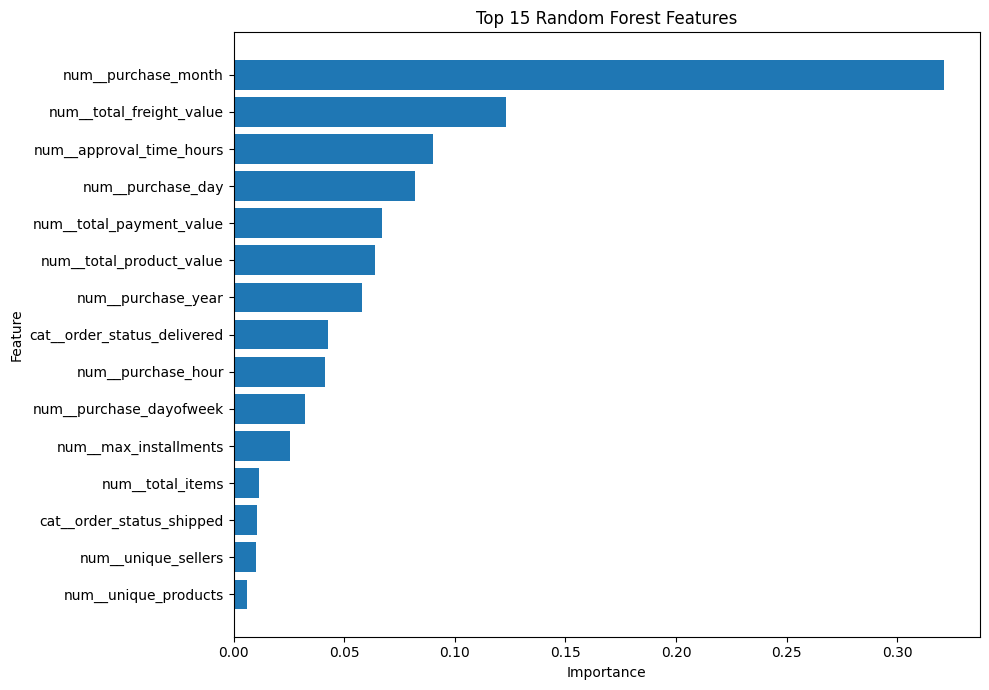

In [303]:
# ============================================================
# RANDOM FOREST - FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Get feature names after preprocessing
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("Number of RF importances:", len(rf_model.feature_importances_))


# ------------------------------------------------------------
# 2. Create feature importance dataframe
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})


# ------------------------------------------------------------
# 3. Sort by importance
# ------------------------------------------------------------

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Display all features
# ------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

print(
    feature_importance.to_string(index=False)
)


# ------------------------------------------------------------
# 5. Top 15 features
# ------------------------------------------------------------

top_features = feature_importance.head(15)

print("\n" + "=" * 60)
print("TOP 15 FEATURES")
print("=" * 60)

print(
    top_features.to_string(index=False)
)


# ------------------------------------------------------------
# 6. Plot Top 15
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.tight_layout()
plt.show()

In [304]:
# ============================================================
# GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("GRADIENT BOOSTING")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create model
# ------------------------------------------------------------

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

gb_model.fit(
    X_train_processed,
    y_train
)

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

y_pred_gb = gb_model.predict(
    X_test_processed
)

y_proba_gb = gb_model.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

gb_precision = precision_score(
    y_test,
    y_pred_gb,
    zero_division=0
)

gb_recall = recall_score(
    y_test,
    y_pred_gb,
    zero_division=0
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb,
    zero_division=0
)

gb_roc_auc = roc_auc_score(
    y_test,
    y_proba_gb
)

gb_pr_auc = average_precision_score(
    y_test,
    y_proba_gb
)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC-AUC  : {gb_roc_auc:.4f}")
print(f"PR-AUC   : {gb_pr_auc:.4f}")


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_gb
    )
)


# ------------------------------------------------------------
# 6. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_gb,
        zero_division=0
    )
)

GRADIENT BOOSTING
Accuracy : 0.9212
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.7396
PR-AUC   : 0.2187

Confusion Matrix:
[[18321     3]
 [ 1565     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     18324
           1       0.00      0.00      0.00      1565

    accuracy                           0.92     19889
   macro avg       0.46      0.50      0.48     19889
weighted avg       0.85      0.92      0.88     19889



In [305]:
# ============================================================
# GRADIENT BOOSTING - THRESHOLD TUNING
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Get probabilities
# ------------------------------------------------------------

y_test_proba_gb = gb_model.predict_proba(
    X_test_processed
)[:, 1]


# ------------------------------------------------------------
# 2. Test thresholds
# ------------------------------------------------------------

thresholds = np.arange(0.05, 0.96, 0.05)

gb_threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_test_proba_gb >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    gb_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })


gb_threshold_results = pd.DataFrame(
    gb_threshold_results
)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 60)
print("GRADIENT BOOSTING - THRESHOLD TUNING")
print("=" * 60)

print(
    gb_threshold_results.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Best threshold based on F1
# ------------------------------------------------------------

best_gb_row = gb_threshold_results.loc[
    gb_threshold_results["f1"].idxmax()
]

best_gb_threshold = best_gb_row["threshold"]

print("\n" + "=" * 60)
print("BEST GRADIENT BOOSTING THRESHOLD")
print("=" * 60)

print(f"Threshold : {best_gb_threshold:.2f}")
print(f"Precision : {best_gb_row['precision']:.4f}")
print(f"Recall    : {best_gb_row['recall']:.4f}")
print(f"F1 Score  : {best_gb_row['f1']:.4f}")


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

y_pred_gb_best = (
    y_test_proba_gb >= best_gb_threshold
).astype(int)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_gb_best
    )
)

GRADIENT BOOSTING - THRESHOLD TUNING
 threshold  precision  recall     f1
      0.05     0.1094  0.8537 0.1940
      0.10     0.2008  0.5406 0.2928
      0.15     0.2522  0.3898 0.3062
      0.20     0.3071  0.2396 0.2692
      0.25     0.3491  0.0990 0.1543
      0.30     0.3478  0.0102 0.0199
      0.35     0.1667  0.0006 0.0013
      0.40     0.0000  0.0000 0.0000
      0.45     0.0000  0.0000 0.0000
      0.50     0.0000  0.0000 0.0000
      0.55     0.0000  0.0000 0.0000
      0.60     0.0000  0.0000 0.0000
      0.65     0.0000  0.0000 0.0000
      0.70     0.0000  0.0000 0.0000
      0.75     0.0000  0.0000 0.0000
      0.80     0.0000  0.0000 0.0000
      0.85     0.0000  0.0000 0.0000
      0.90     0.0000  0.0000 0.0000
      0.95     0.0000  0.0000 0.0000

BEST GRADIENT BOOSTING THRESHOLD
Threshold : 0.15
Precision : 0.2522
Recall    : 0.3898
F1 Score  : 0.3062

Confusion Matrix:
[[16515  1809]
 [  955   610]]


In [307]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# ============================================================
# MODEL COMPARISON AFTER THRESHOLD TUNING
# ============================================================

models_predictions = {
    "Logistic Regression": logistic_model.predict_proba(X_test_processed)[:, 1],
    "Random Forest": rf_model.predict_proba(X_test_processed)[:, 1],
    "Gradient Boosting": gb_model.predict_proba(X_test_processed)[:, 1]
}

thresholds = np.arange(0.05, 0.51, 0.01)

results = []

for model_name, y_prob in models_predictions.items():

    best_f1 = -1
    best_threshold = 0
    best_precision = 0
    best_recall = 0

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_precision = precision
            best_recall = recall

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Best Threshold": round(best_threshold, 2),
        "Precision": round(best_precision, 4),
        "Recall": round(best_recall, 4),
        "F1": round(best_f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "PR-AUC": round(pr_auc, 4)
    })

model_comparison = pd.DataFrame(results)

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(model_comparison.to_string(index=False))

FINAL MODEL COMPARISON
              Model  Best Threshold  Precision  Recall     F1  ROC-AUC  PR-AUC
Logistic Regression            0.49     0.1009  0.7042 0.1765   0.5997  0.0996
      Random Forest            0.50     0.2022  0.5412 0.2945   0.7482  0.2149
  Gradient Boosting            0.14     0.2469  0.4307 0.3139   0.7396  0.2187


In [308]:
from sklearn.metrics import confusion_matrix, classification_report

# ============================================================
# FINAL MODEL CONFUSION MATRICES
# ============================================================

final_thresholds = {
    "Random Forest": 0.50,
    "Gradient Boosting": 0.15
}

final_models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for model_name, model in final_models.items():

    threshold = final_thresholds[model_name]

    y_prob = model.predict_proba(X_test_processed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 70)
    print(model_name)
    print("Threshold:", threshold)
    print("=" * 70)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    ))


Random Forest
Threshold: 0.5

Confusion Matrix:
[[14983  3341]
 [  718   847]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9543    0.8177    0.8807     18324
           1     0.2022    0.5412    0.2945      1565

    accuracy                         0.7959     19889
   macro avg     0.5783    0.6794    0.5876     19889
weighted avg     0.8951    0.7959    0.8346     19889


Gradient Boosting
Threshold: 0.15

Confusion Matrix:
[[16515  1809]
 [  955   610]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9453    0.9013    0.9228     18324
           1     0.2522    0.3898    0.3062      1565

    accuracy                         0.8610     19889
   macro avg     0.5988    0.6455    0.6145     19889
weighted avg     0.8908    0.8610    0.8743     19889



TOP 15 RANDOM FOREST FEATURES
                    feature  importance
        num__purchase_month    0.321374
   num__total_freight_value    0.123103
   num__approval_time_hours    0.090200
          num__purchase_day    0.081907
   num__total_payment_value    0.067174
   num__total_product_value    0.064178
         num__purchase_year    0.058042
cat__order_status_delivered    0.042860
         num__purchase_hour    0.041270
    num__purchase_dayofweek    0.032099
      num__max_installments    0.025405
           num__total_items    0.011415
  cat__order_status_shipped    0.010522
        num__unique_sellers    0.010099
       num__unique_products    0.005975


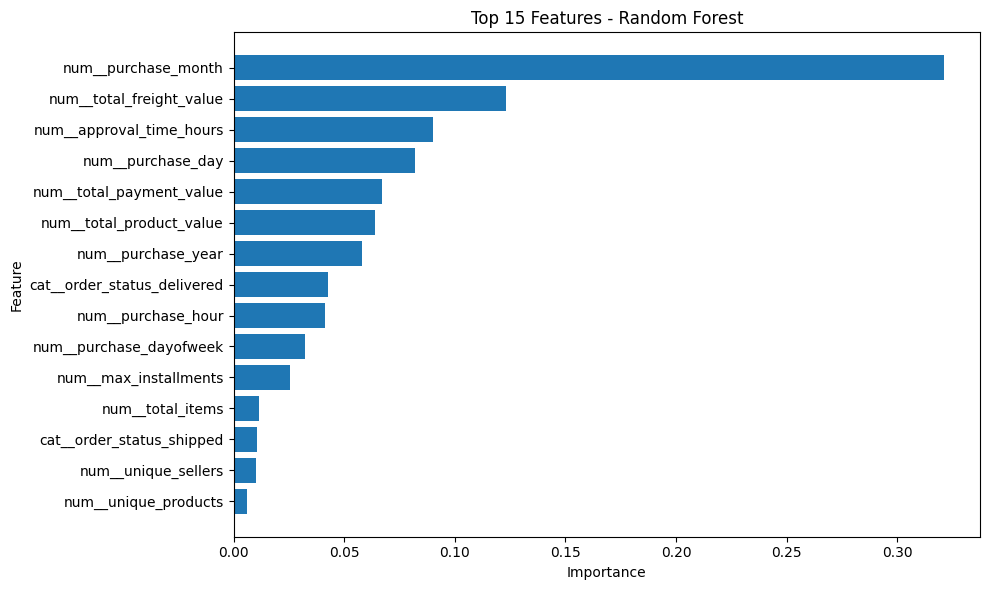

In [310]:
import matplotlib.pyplot as plt

# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_names = preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
).head(15)

print("=" * 70)
print("TOP 15 RANDOM FOREST FEATURES")
print("=" * 70)

print(rf_importance.to_string(index=False))

plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["feature"][::-1],
    rf_importance["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")

plt.tight_layout()
plt.show()

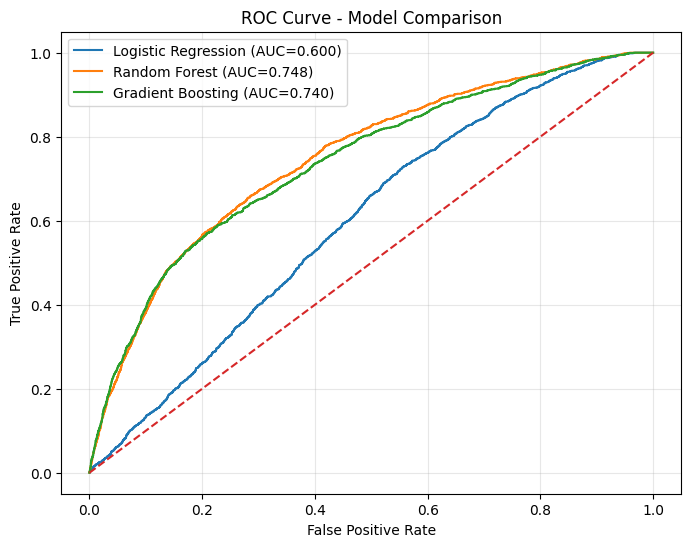

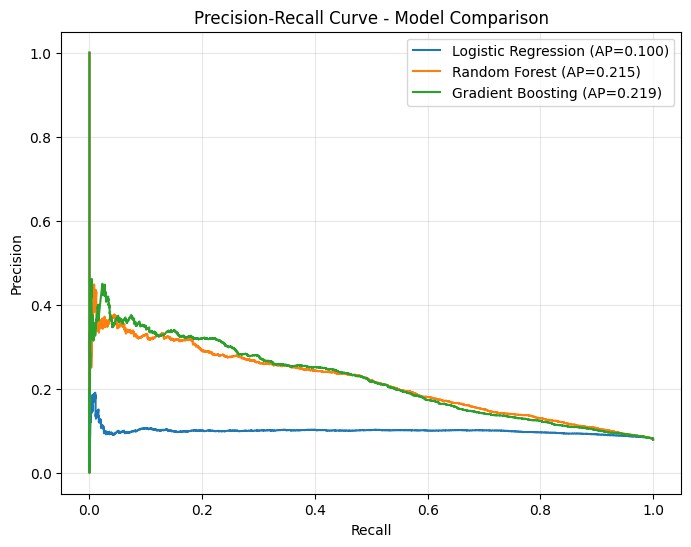

In [312]:
#ROC + Precision-Recall Curves
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)
import matplotlib.pyplot as plt

# ============================================================
# MODEL PROBABILITIES
# ============================================================

lr_proba = logistic_model.predict_proba(X_test_processed)[:, 1]
rf_proba = rf_model.predict_proba(X_test_processed)[:, 1]
gb_proba = gb_model.predict_proba(X_test_processed)[:, 1]

# ============================================================
# ROC CURVE
# ============================================================

plt.figure(figsize=(8, 6))

for name, proba in [
    ("Logistic Regression", lr_proba),
    ("Random Forest", rf_proba),
    ("Gradient Boosting", gb_proba)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(8, 6))

for name, proba in [
    ("Logistic Regression", lr_proba),
    ("Random Forest", rf_proba),
    ("Gradient Boosting", gb_proba)
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [313]:
# ============================================================
# FINAL MODEL BUSINESS INTERPRETATION
# ============================================================

final_threshold = 0.15

gb_pred_final = (gb_proba >= final_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, gb_pred_final)

tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("FINAL GRADIENT BOOSTING MODEL")
print("=" * 60)

print("Threshold:", final_threshold)

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nClassification Report:")
print(classification_report(y_test, gb_pred_final))

FINAL GRADIENT BOOSTING MODEL
Threshold: 0.15

Confusion Matrix:
[[16515  1809]
 [  955   610]]

True Negatives : 16515
False Positives: 1809
False Negatives: 955
True Positives : 610

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     18324
           1       0.25      0.39      0.31      1565

    accuracy                           0.86     19889
   macro avg       0.60      0.65      0.61     19889
weighted avg       0.89      0.86      0.87     19889



In [314]:
# ============================================================
# DELIVERY RISK SEGMENTATION
# ============================================================

risk_data = pd.DataFrame({
    "actual": y_test.values,
    "probability": gb_proba
})

risk_data["risk_level"] = pd.cut(
    risk_data["probability"],
    bins=[-0.01, 0.10, 0.30, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("=" * 60)
print("RISK SEGMENTATION")
print("=" * 60)

print("\nNumber of orders per risk level:")
print(risk_data["risk_level"].value_counts().sort_index())

print("\nActual late-delivery rate by risk level:")

risk_summary = (
    risk_data
    .groupby("risk_level", observed=False)["actual"]
    .agg(
        orders="count",
        late_orders="sum",
        late_rate="mean"
    )
)

risk_summary["late_rate"] = risk_summary["late_rate"] * 100

print(risk_summary)

RISK SEGMENTATION

Number of orders per risk level:
risk_level
Low Risk       15675
Medium Risk     4168
High Risk         46
Name: count, dtype: int64

Actual late-delivery rate by risk level:
             orders  late_orders  late_rate
risk_level                                 
Low Risk      15675          719   4.586922
Medium Risk    4168          830  19.913628
High Risk        46           16  34.782609


In [315]:
# ============================================================
# HIGH RISK ORDERS
# ============================================================

high_risk = X_test.copy()

high_risk["late_probability"] = gb_proba

high_risk["risk_level"] = pd.cut(
    high_risk["late_probability"],
    bins=[-0.01, 0.10, 0.30, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

high_risk_orders = (
    high_risk[
        high_risk["risk_level"] == "High Risk"
    ]
    .sort_values("late_probability", ascending=False)
)

print("=" * 60)
print("TOP HIGH-RISK ORDERS")
print("=" * 60)

print(
    high_risk_orders[
        [
            "late_probability",
            "risk_level"
        ]
    ].head(20)
)

TOP HIGH-RISK ORDERS
       late_probability risk_level
88721          0.617878  High Risk
74778          0.546774  High Risk
55657          0.523267  High Risk
16218          0.373567  High Risk
4069           0.360123  High Risk
82408          0.352508  High Risk
92219          0.348035  High Risk
75201          0.344527  High Risk
16658          0.337656  High Risk
65095          0.333204  High Risk
65039          0.332767  High Risk
96836          0.330221  High Risk
97615          0.325617  High Risk
86705          0.324980  High Risk
80672          0.323560  High Risk
46223          0.321758  High Risk
94345          0.320238  High Risk
22868          0.319817  High Risk
48140          0.319460  High Risk
67625          0.318781  High Risk


In [316]:
# ============================================================
# GRADIENT BOOSTING FEATURE IMPORTANCE
# ============================================================

feature_names = preprocessor.get_feature_names_out()

gb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="importance",
    ascending=False
)

print("=" * 60)
print("TOP 15 GRADIENT BOOSTING FEATURES")
print("=" * 60)

print(gb_importance.head(15).to_string(index=False))

TOP 15 GRADIENT BOOSTING FEATURES
                    feature  importance
        num__purchase_month    0.464762
   num__total_freight_value    0.156378
         num__purchase_year    0.122855
          num__purchase_day    0.114464
   num__approval_time_hours    0.040708
cat__order_status_delivered    0.039067
   num__total_product_value    0.019154
           num__total_items    0.011869
    num__purchase_dayofweek    0.009266
        num__unique_sellers    0.008167
   num__total_payment_value    0.005519
         num__purchase_hour    0.004847
      num__max_installments    0.002130
       num__unique_products    0.000796
         num__payment_count    0.000019


In [318]:
# ============================================================
# FINAL ML OUTPUT - SAVE PREDICTIONS & RISK SEGMENTATION
# ============================================================

# Test predictions using the final Gradient Boosting model
final_probabilities = gb_proba

# Use the selected threshold
final_threshold = 0.15

# Convert probabilities to predictions
final_predictions = (final_probabilities >= final_threshold).astype(int)

# Create final ML results
ml_results = X_test.copy()

ml_results["late_probability"] = final_probabilities
ml_results["predicted_late"] = final_predictions
ml_results["actual_late_delivery"] = y_test.values

# Risk segmentation
ml_results["risk_level"] = pd.cut(
    ml_results["late_probability"],
    bins=[-np.inf, 0.10, 0.30, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("=" * 60)
print("FINAL ML RESULTS")
print("=" * 60)

print("\nShape:")
print(ml_results.shape)

print("\nRisk distribution:")
print(ml_results["risk_level"].value_counts())

print("\nActual late rate by risk:")
print(
    ml_results.groupby("risk_level", observed=True)["actual_late_delivery"]
    .agg(["count", "sum", "mean"])
)

# Save results
ml_results.to_csv(
    "cleaned_data/final_ml_predictions.csv",
    index=False
)

print("\nSaved:")
print("cleaned_data/final_ml_predictions.csv")

FINAL ML RESULTS

Shape:
(19889, 19)

Risk distribution:
risk_level
Low Risk       15675
Medium Risk     4168
High Risk         46
Name: count, dtype: int64

Actual late rate by risk:
             count  sum      mean
risk_level                       
Low Risk     15675  719  0.045869
Medium Risk   4168  830  0.199136
High Risk       46   16  0.347826

Saved:
cleaned_data/final_ml_predictions.csv


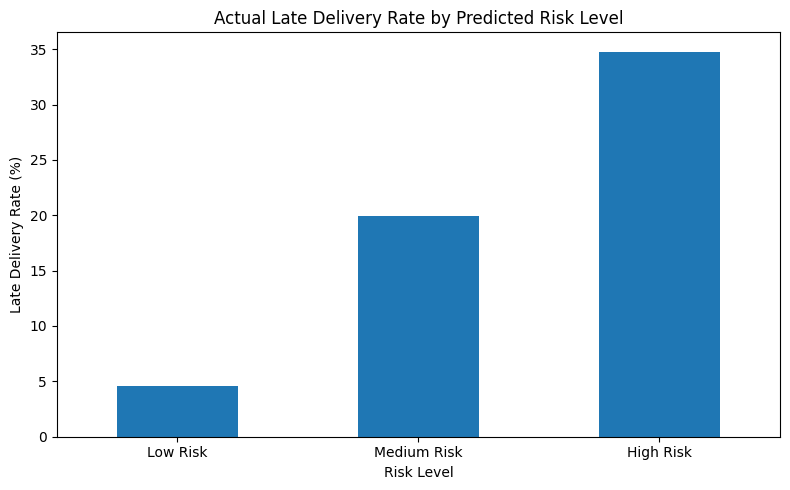

In [319]:
# ============================================================
# RISK LEVEL VS ACTUAL LATE DELIVERY RATE
# ============================================================

risk_summary = (
    ml_results
    .groupby("risk_level", observed=True)["actual_late_delivery"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))

risk_summary.plot(kind="bar")

plt.title("Actual Late Delivery Rate by Predicted Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

FINAL GRADIENT BOOSTING MODEL

Threshold: 0.15

Classification Report:
              precision    recall  f1-score   support

           0     0.9453    0.9013    0.9228     18324
           1     0.2522    0.3898    0.3062      1565

    accuracy                         0.8610     19889
   macro avg     0.5988    0.6455    0.6145     19889
weighted avg     0.8908    0.8610    0.8743     19889


Confusion Matrix:
[[16515  1809]
 [  955   610]]

True Negatives : 16515
False Positives: 1809
False Negatives: 955
True Positives : 610


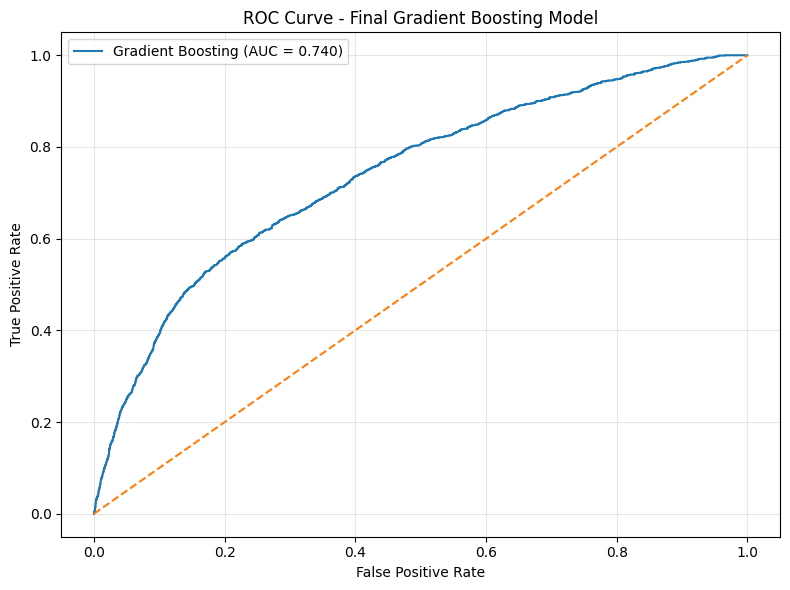

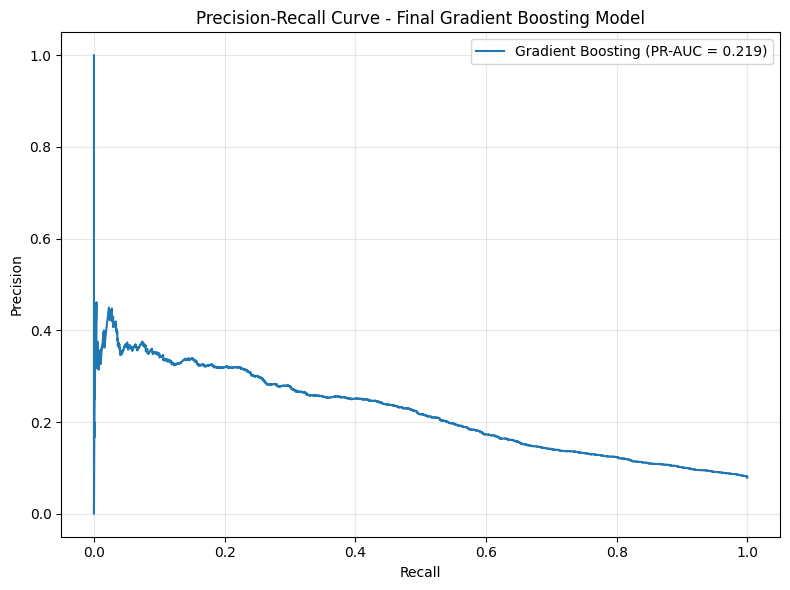


TOP 15 FEATURES
                    feature  importance
        num__purchase_month    0.464762
   num__total_freight_value    0.156378
         num__purchase_year    0.122855
          num__purchase_day    0.114464
   num__approval_time_hours    0.040708
cat__order_status_delivered    0.039067
   num__total_product_value    0.019154
           num__total_items    0.011869
    num__purchase_dayofweek    0.009266
        num__unique_sellers    0.008167
   num__total_payment_value    0.005519
         num__purchase_hour    0.004847
      num__max_installments    0.002130
       num__unique_products    0.000796
         num__payment_count    0.000019


In [320]:
# ============================================================
# FINAL ML EVALUATION PACK
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# Final predictions
# ------------------------------------------------------------

final_threshold = 0.15

final_probabilities = gb_model.predict_proba(
    X_test_processed
)[:, 1]

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)

# ------------------------------------------------------------
# 1. Classification Report
# ------------------------------------------------------------

print("=" * 70)
print("FINAL GRADIENT BOOSTING MODEL")
print("=" * 70)

print("\nThreshold:", final_threshold)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 2. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    final_predictions
)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

# ------------------------------------------------------------
# 3. ROC Curve
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test,
    final_probabilities
)

roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Gradient Boosting Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Precision-Recall Curve
# ------------------------------------------------------------

precision, recall, _ = precision_recall_curve(
    y_test,
    final_probabilities
)

pr_auc = average_precision_score(
    y_test,
    final_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Gradient Boosting (PR-AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Gradient Boosting Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Feature Importance
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print("\n" + "=" * 70)
print("TOP 15 FEATURES")
print("=" * 70)

print(
    feature_importance
    .head(15)
    .to_string(index=False)
)

# THE DISCOVERY

## MISSION: Go Beyond the Data. Find the Story.

### 1. What is happening in the business?

The analysis shows a large and active e-commerce operation with **99,441 orders**.

Most orders were successfully delivered, with **96,478 delivered orders**, while the remaining orders were distributed across shipped, canceled, unavailable, invoiced, processing, created, and approved statuses.

From a delivery perspective, **7.87% of all orders were classified as late**, while **92.13% were not late**.

The business therefore has a generally high on-time delivery rate, but late delivery remains a significant operational issue because thousands of orders are affected.

The analysis also shows that order value and freight costs vary considerably. The average product value per order was approximately **137.75**, while the average freight value was approximately **22.82**.

---

### 2. Where are the frictions or challenges?

The main operational friction identified in the analysis is **delivery performance**.

There are **7,827 late orders**, which means that late delivery is not an isolated event.

The analysis also revealed substantial variation in late-delivery rates across time periods. For example:

* March had a late-delivery rate of **16.56%**
* November had **13.83%**
* February had **12.95%**
* June had the lowest observed rate at approximately **2.17%**

This indicates that delivery performance is not constant throughout the year.

Another challenge is that the late-delivery problem is difficult to predict perfectly. The final Gradient Boosting model achieved approximately **39% recall** for late orders, meaning a considerable proportion of actual late deliveries were still not identified by the model.

---

### 3. What patterns or trends deserve attention?

Several patterns deserve management attention.

#### Seasonal pattern

Late delivery varies substantially by month.

The highest late-delivery rates were observed in:

* March: **16.56%**
* November: **13.83%**
* February: **12.95%**

while June had a much lower rate of **2.17%**.

This suggests that time of purchase is an important signal for delivery risk.

#### Yearly pattern

The late-delivery rate increased across the available years:

* 2016: **1.22%**
* 2017: **6.38%**
* 2018: **9.16%**

This temporal change deserves investigation because it indicates that delivery performance differed considerably across the observed years.

#### Freight pattern

Late orders had a higher average freight value:

* On-time orders: **22.67**
* Late orders: **24.62**

The correlation between freight value and late delivery was positive, although relatively weak (**0.024**). Therefore, freight value is associated with the prediction model but should not be interpreted as a direct cause of late delivery.

#### Risk pattern

The machine learning model produced three risk segments:

| Risk Level  | Orders | Actual Late Rate |
| ----------- | -----: | ---------------: |
| Low Risk    | 15,675 |            4.59% |
| Medium Risk |  4,168 |           19.91% |
| High Risk   |     46 |           34.78% |

The actual late-delivery rate increases substantially across the risk groups, making risk segmentation potentially useful for operational prioritization.

---

### 4. What would management need to understand?

Management should understand that **overall delivery performance can hide important differences between time periods and individual orders**.

Although the overall late-delivery rate is **7.87%**, the monthly analysis shows that some periods experienced considerably higher rates.

The machine learning analysis also indicates that delivery risk can be estimated before the final delivery outcome is known, although the model is not perfect.

The most influential variables in the final Gradient Boosting model included:

* Purchase month
* Total freight value
* Purchase year
* Purchase day
* Approval time
* Order status
* Total product value

This suggests that management can monitor **when orders are placed, their freight characteristics, and other order-level information** when designing delivery-risk monitoring processes.

The risk segmentation can additionally be used to prioritize operational attention rather than treating every order identically.

---

### 5. What evidence supports your conclusions?

The conclusions are supported by multiple layers of analysis:

**Business data**

* 99,441 total orders
* 96,478 delivered orders
* 7,827 late orders
* 7.87% overall late-delivery rate

**EDA**

* Monthly late-delivery rates varied from approximately **2.17% to 16.56%**
* Yearly late-delivery rates increased from **1.22% in 2016 to 9.16% in 2018**
* Late orders had higher average freight value than on-time orders

**SQL Analysis**

The SQL analysis connected the individual datasets to investigate:

* Sales and revenue
* Customers and sellers
* Delivery performance
* Products
* Reviews and customer satisfaction

**Machine Learning**

The final Gradient Boosting model achieved:

* Accuracy: **86.10%**
* Precision: **25.22%**
* Recall: **38.98%**
* F1-score: **30.62%**
* ROC-AUC: **73.96%**
* PR-AUC: **21.87%**

Most importantly, the risk segmentation showed:

**4.59% late rate → Low Risk**
**19.91% late rate → Medium Risk**
**34.78% late rate → High Risk**

This provides quantitative evidence that the model's risk scores contain useful information about observed late-delivery patterns.

---

# THE STORY BEHIND THE DATA

The central story of the analysis is that **Olist's overall delivery performance appears strong at the aggregate level, but the experience is not uniform across all orders and time periods.**

Late delivery is concentrated differently across months and years, and the machine learning model identifies order characteristics associated with higher delivery risk.

Therefore, the key opportunity is not simply to measure how many orders are late, but to **identify when and which orders are more exposed to delivery risk and prioritize them for monitoring**.

The analysis transforms the dataset from a collection of transactions into a business decision-support framework:

**Understand the pattern → Identify the risk → Prioritize attention → Monitor delivery performance.**
